# Chandrayaan-2 TMC-2 Preprocessing + Encoder Pipeline
### SIH -- Multi-modal, Sun-angle & Scale Invariant Lunar Image Correspondence
### Track owner: TMC-2 preprocessing & visual encoder (OHRC and IIRS are separate notebooks/teammates)

This notebook implements **only** the TMC-2 side of the pipeline:

```
TMC-2 calibrated products (NCF/NCN/NCA)
        |
product/observation discovery
        |
PDS4/XML interpretation
        |
memory-efficient .IMG reading
        |
geometry + ancillary metadata association
        |
orientation handling
        |
image preprocessing (2-channel: structural + illumination-invariant)
        |
256x256 patch extraction
        |
quality filtering + spatially balanced sampling
        |
TMC-2 visual encoder (ResNet-18, 2-channel in)
        |
256-D embedding (+ optional 128-D contrastive projection)
        |
embedding + complete patch metadata (NPZ + manifest)
```

## What the TMC-2 documentation says, and how that shapes this notebook

This notebook was built from two supplied documents:

* `ch2_tmc2_data_products_user_guide_1.pdf` -- the TMC2 PDS4 Data Products **User Guide** (37 pages)
* `ch2_tmc2_pds_dp_archive_sis.pdf` -- the TMC2 PDS4 Data Products and Archive **Software Interface Specification** (62 pages, more detailed and more recently revised)

| Documented TMC-2 fact | Where it came from | Consequence for this notebook |
|---|---|---|
| TMC-2 is **panchromatic** (0.50-0.85 micron), **5 m/pixel**, **20 km swath**, from a ~100 km polar orbit, with three sensors **Fore (-25 deg), Nadir (0 deg), Aft (+25 deg)** along track | SIS Sec. 2/3, Table 3, Table 5 | One structural channel is enough (no band reduction, unlike IIRS). Camera identity (Fore/Nadir/Aft) is preserved end-to-end as natural viewpoint diversity, per the problem statement. |
| Calibrated (`nc*`) and Raw (`nr*`) images are **generic binary**, `UnsignedLSB2` (UInt16 little-endian), with a **detached PDS4 XML label**; Browse images are `UnsignedByte` PNG | User Guide Table 7 / SIS Table 26 | We never hard-code dimensions or dtype -- both are parsed from each product's own XML `Array_2D_Image` block. |
| Filenames follow `ch2_<inst>_<mtc>_<YYYYMMDDTHHMMSSssss>_<p>_<prd>_<stn>.<fff>`, where the 3-letter `<mtc>` code packs mission-phase + product-type + camera (e.g. `ncf` = nop + calibrated + fore) | User Guide Annexure I / SIS Sec. 6.5 | Discovery parses this token instead of assuming directory depth, and extracts camera identity directly from the filename. |
| Archive layout is `browse/`, `data/`, `geometry/`, `miscellaneous/` (+ `calibration/`, `context/`, `document/`, `xml_schema/`), each split by `raw/ calibrated/ derived` and then `yyyymmdd` | SIS Sec. 6.3-6.4 | Discovery walks recursively and classifies by regex, not by assumed folder depth -- robust to a flat unzipped folder or a partial extraction. |
| Geometry is a **CSV grid** with `Longitude, Latitude, Scan, Pixel` columns, plus corner coordinates (`System_Level_Coordinates`, `Refined_Corner_Coordinates`) inside the image XML label | SIS Table 26 + Appendix D sample label | Tile-center lat/lon comes from the grid via interpolation; the four XML corners are kept as a coarse fallback/consistency check when the grid is sparse or missing. |
| Orientation depends on `orbit_limb_direction` (Ascending/Descending) and `spacecraft_yaw_direction` (True=Reverse/False=Forward) | User Guide Sec. 6 local data dictionary; SIS Appendix G (Table 29) | We implement the documented rule as an explicit lookup table -- **not** a "flip until it looks right" heuristic. **Important documentation discrepancy, flagged rather than silently resolved**: the User Guide and the (more detailed, more recently revised) Archive SIS state the *same* rule for cases 1 and 2 but *disagree* on cases 3 and 4 (which axis gets reversed for Ascending). This notebook defaults to the Archive SIS version and exposes `ORIENTATION_RULE_SOURCE` so the assumption is explicit and swappable. |
| Miscellaneous directory holds `.oat` (orbit & attitude), `.oath` (OAT header), `.lbr` (libration angle) and `.spm` (sun parameters) as plain **ASCII text**, with no documented column/field schema | User Guide Sec 3.1/3.2 Table 4/5; SIS Sec 6.4.9 | We do **not** invent a fixed column layout. A generic, best-effort key/value + numeric-token parser extracts whatever it can, and every field that can't be confidently identified is left `NaN` with a `MISSING_ANCILLARY`/QA flag rather than a guessed value. |
| Only `img`/`xml`/`jpg`/`csv`/`tif` are documented file-type extensions in Annexure I / Sec 6.5 (`oat/oath/lbr/spm` are not in that table) | Both documents | Ancillary-file discovery is therefore **content/suffix based** (glob by extension + shared filename token), explicitly called out as an assumption rather than a documented naming rule. |

### Output contract (matches the OHRC / IIRS notebooks' conventions)
Every TMC-2 patch produces:
1. one `.npz` file with a **(2, 256, 256) float32** array -- channel 0 = normalized calibrated intensity, channel 1 = Weber-style illumination-invariant local contrast
2. one manifest row (CSV + JSONL) with the complete source/patch identity (Sec 18 of the brief)

The encoder consumes these two channels and emits a **256-D `tmc2_embedding_256`** (never anonymous, always joined to its manifest row), with an optional 128-D projection head used only for contrastive training.


## 1. Environment setup

In [1]:
# ============================================================
# TMC-2 PREPROCESSING - ENVIRONMENT SETUP
# ============================================================
# Local Windows/Jupyter environment.
# Install the handful of extra packages this notebook actually needs.

%pip -q install scikit-image scikit-learn --upgrade


# ============================================================
# STANDARD LIBRARY
# ============================================================

import os
import re
import io
import glob
import json
import math
import zipfile
import shutil
import tempfile
import warnings
import dataclasses

from dataclasses import dataclass, field, asdict

from typing import (
    Optional,
    List,
    Dict,
    Tuple,
    Any
)

from datetime import (
    datetime,
    timezone
)

from pathlib import Path

import xml.etree.ElementTree as ET


# ============================================================
# NUMPY / PANDAS
# ============================================================

import numpy as np
import pandas as pd


# ============================================================
# SCIPY
# ============================================================

from scipy.ndimage import gaussian_filter
from scipy.interpolate import griddata


# ============================================================
# VISUALIZATION
# ============================================================

import matplotlib.pyplot as plt


# ============================================================
# WARNINGS / RANDOM SEED
# ============================================================

warnings.filterwarnings("ignore")

RNG_SEED = 42

np.random.seed(
    RNG_SEED
)


# ============================================================
# ENVIRONMENT CHECK
# ============================================================

print("=" * 70)
print("TMC-2 ENVIRONMENT READY")
print("=" * 70)

print("Python environment initialized.")
print("NumPy version :", np.__version__)
print("Pandas version:", pd.__version__)
print("Random seed   :", RNG_SEED)

print("=" * 70)


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
TMC-2 ENVIRONMENT READY
Python environment initialized.
NumPy version : 2.2.6
Pandas version: 2.2.2
Random seed   : 42


## 2. Configuration

Every important knob lives here. Nothing below this cell hard-codes a
path, a dimension, a threshold or an observation count -- edit this
cell to point at your data and to retune the pipeline.

`TMC2_DIR` should point at a folder that contains (in any nesting --
discovery is recursive) either:
* raw unzipped PDS4 archive folders (`browse/ data/ geometry/
  miscellaneous/ ...`), or
* a flat pile of extracted `*.img/*.xml/*.csv/*.oat/...` files, or
* `.zip` product bundles (`ch2_tmc_ncf_..._d_img_d18.zip` etc.), which
  are discovered and lazily extracted one at a time.

No Google Drive mount is required (though it is fine to point
`TMC2_DIR` at a mounted Drive folder if that's where the data lives).

In [2]:
# ============================================================
# TMC-2 CONFIGURATION
# ============================================================

# ---- Paths -------------------------------------------------

# Local Windows project root.
PROJECT_ROOT = r"D:\ISRO"

# Root containing one or more extracted TMC-2 data-point folders.
# Discovery is recursive, so the individual data-point folder
# does NOT need to be specified here.
TMC2_DIR = os.path.join(
    PROJECT_ROOT,
    "TMC_raws"
)

# TMC-2 processed output directory.
OUT_ROOT = os.path.join(
    PROJECT_ROOT,
    "TMC_tiles"
)

os.makedirs(OUT_ROOT, exist_ok=True)

PATCH_DIR = os.path.join(
    OUT_ROOT,
    "patches"
)

os.makedirs(PATCH_DIR, exist_ok=True)


# ---- Observation grouping ----------------------------------

# Fore/Nadir/Aft images can correspond to the same ground swath
# at different times, so exact timestamp equality is not required.
OBS_GROUP_MAX_TIME_DELTA_SEC = 180.0


# ---- Train / test split ------------------------------------

N_TRAIN_OBSERVATIONS = 15
N_TEST_OBSERVATIONS = 5
SPLIT_AT_OBSERVATION_LEVEL = True


# ---- Orientation -------------------------------------------

# Archive SIS is the default documented rule.
ORIENTATION_RULE_SOURCE = "archive_sis"

# Valid alternatives:
# "archive_sis"
# "user_guide"


# ---- Patch extraction --------------------------------------

PATCH_SIZE = 256
PATCH_STRIDE = 256


# ---- Quality filtering -------------------------------------

NODATA_DN = 0
MAX_SATURATION_DN = 4095
MIN_VALID_FRACTION = 0.90
MAX_SATURATION_FRACTION = 0.25
MIN_ENTROPY = 3.0


# ---- Spatially balanced sampling --------------------------

SPATIAL_GRID_CELLS_PER_OBS = (4, 4)
MAX_PATCHES_PER_SPATIAL_CELL = 40
MAX_PATCHES_PER_OBSERVATION = 400


# ---- Illumination-robust channel --------------------------

WEBER_SIGMA_PX = 15.0
WEBER_EPS = 1e-3
NORM_LOW_PCT = 1.0
NORM_HIGH_PCT = 99.0


# ---- Encoder -----------------------------------------------

IN_CHANNELS = 2
EMBED_DIM = 256
PROJ_DIM = 128
PRETRAINED_BACKBONE = True


# ---- Geometry interpolation -------------------------------

GEOMETRY_INTERP_METHOD = "linear"


# ---- Print configuration -----------------------------------

print("=" * 70)
print("TMC-2 LOCAL WINDOWS CONFIGURATION")
print("=" * 70)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("TMC2_DIR:", TMC2_DIR)
print("OUT_ROOT:", OUT_ROOT)
print("PATCH_DIR:", PATCH_DIR)
print("Patch size / stride:", PATCH_SIZE, "/", PATCH_STRIDE)
print(
    "Train / test observation counts:",
    N_TRAIN_OBSERVATIONS,
    "/",
    N_TEST_OBSERVATIONS
)
print("Orientation rule:", ORIENTATION_RULE_SOURCE)
print("Encoder embedding dimension:", EMBED_DIM)
print("Encoder projection dimension:", PROJ_DIM)
print("=" * 70)

TMC-2 LOCAL WINDOWS CONFIGURATION
PROJECT_ROOT: D:\ISRO
TMC2_DIR: D:\ISRO\TMC_raws
OUT_ROOT: D:\ISRO\TMC_tiles
PATCH_DIR: D:\ISRO\TMC_tiles\patches
Patch size / stride: 256 / 256
Train / test observation counts: 15 / 5
Orientation rule: archive_sis
Encoder embedding dimension: 256
Encoder projection dimension: 128


## 3. QA statuses and the shared patch-metadata schema

`QAStatus` gives every product/patch an explicit, machine-checkable
outcome instead of a silent `None`. `TMCPatchMetadata` is the TMC-2
implementation of the same "one manifest row per patch, complete
source identity, no anonymous embeddings" contract the OHRC and IIRS
notebooks use (Sec. 18 of the brief), extended with the TMC-2-specific
fields (camera, orbit number, orientation transform, etc.).

In [3]:
# ============================================================
# QA STATUSES + SHARED METADATA SCHEMA
# ============================================================

class QAStatus:
    MISSING_XML = "MISSING_XML"
    INVALID_XML = "INVALID_XML"
    INVALID_DIMENSIONS = "INVALID_DIMENSIONS"
    UNSUPPORTED_DTYPE = "UNSUPPORTED_DTYPE"
    IMG_SIZE_MISMATCH = "IMG_SIZE_MISMATCH"
    MISSING_GEOMETRY = "MISSING_GEOMETRY"
    MISSING_ANCILLARY = "MISSING_ANCILLARY"
    INVALID_PATCH = "INVALID_PATCH"
    INVALID_GEOLOCATION = "INVALID_GEOLOCATION"
    SUCCESS = "SUCCESS"


@dataclass
class TMCPatchMetadata:
    # --- identity -------------------------------------------------------
    patch_id: str
    source_scene_id: str
    source_product_id: str
    observation_id: str
    camera: str
    sensor_id: str = "TMC2"
    processing_level: str = "Calibrated"

    # --- acquisition / orbit ---------------------------------------------
    observation_time_utc: Optional[str] = None
    imaging_orbit_number: Optional[int] = None
    dumping_orbit_number: Optional[int] = None
    orbit_limb_direction: Optional[str] = None
    spacecraft_yaw_direction: Optional[str] = None
    spacecraft_altitude_km: float = float("nan")
    line_exposure_duration_ms: float = float("nan")
    gain: Optional[str] = None
    exposure: Optional[str] = None
    pixel_resolution_m: float = float("nan")

    # --- geometry ----------------------------------------------------------
    original_image_lines: Optional[int] = None
    original_image_samples: Optional[int] = None
    patch_row0: int = 0
    patch_col0: int = 0
    patch_size_px: int = PATCH_SIZE
    tile_row: int = 0
    tile_col: int = 0
    lat: float = float("nan")
    lon: float = float("nan")
    geolocation_source: str = "unknown"

    # --- illumination / ancillary -------------------------------------------
    sun_azimuth_deg: float = float("nan")
    sun_elevation_deg: float = float("nan")
    solar_incidence_deg: float = float("nan")
    libration_lat_deg: float = float("nan")
    libration_lon_deg: float = float("nan")
    oat_summary: Optional[str] = None
    oath_summary: Optional[str] = None

    # --- orientation / preprocessing provenance ------------------------------
    orientation_reverse_lines: bool = False
    orientation_reverse_samples: bool = False
    orientation_rule_source: str = ORIENTATION_RULE_SOURCE
    norm_lo: float = float("nan")
    norm_hi: float = float("nan")
    preprocessing_version: str = "tmc2_pipeline_v1"

    # --- QA -------------------------------------------------------------
    valid_fraction: float = 1.0
    saturation_fraction: float = 0.0
    entropy: float = float("nan")
    flag_low_texture: bool = False
    flag_geoloc_missing: bool = False
    flag_ancillary_missing: bool = False
    qa_status: str = QAStatus.SUCCESS

    # --- output ------------------------------------------------------------
    patch_npz_path: str = ""


def check_dict_for_nans(meta: dict, keys) -> List[str]:
    # Generic helper used by several sections below to log rather than
    # silently propagate missing ancillary/geometry fields.
    problems = []

    for k in keys:
        v = meta.get(k)

        if v is None or (
            isinstance(v, float) and math.isnan(v)
        ):
            problems.append(f"missing {k}")

    return problems


print("QAStatus + TMCPatchMetadata defined.")

QAStatus + TMCPatchMetadata defined.


## 4. Filename parsing (Annexure I / Sec. 6.5)

`ch2_<inst>_<mtc>_<YYYYMMDDTHHMMSSssss>_<p>_<prd>_<stn>.<fff>`

The 3-character `<mtc>` token packs three single-letter codes:
mission-phase (`e`=Earth-bound, `n`=Normal-Ops) + product-type
(`r`=raw, `c`=calibrated, `d`=derived) + camera (`f`=Fore, `a`=Aft,
`n`=Nadir). e.g. `ncf` = nop + calibrated + fore.

In [4]:
# ============================================================
# FILENAME PARSING
# ============================================================

TMC2_NAME_RE = re.compile(
    r"ch2_(?P<inst>[a-z]{3})_(?P<mtc>[a-z]{3})_(?P<stamp>\d{8}T\d{10,13})"
    r"_(?P<p>[dbg])_(?P<prd>img|brw|grd|dtm|orh|oth)_(?P<stn>[a-z0-9]+)",
    re.IGNORECASE,
)

MISSION_PHASE_MAP = {
    "e": "earth_bound",
    "n": "normal_ops",
}

PRODUCT_TYPE_MAP = {
    "r": "raw",
    "c": "calibrated",
    "d": "derived",
}

CAMERA_MAP = {
    "f": "FORE",
    "a": "AFT",
    "n": "NADIR",
}


def parse_timestamp_token(stamp: str) -> Optional[datetime]:
    # YYYYMMDDTHHMMSSssss where ssss = 1/10 ms (100 microsecond) units.
    try:
        base = datetime.strptime(
            stamp[:15],
            "%Y%m%dT%H%M%S"
        )

        frac = stamp[15:19]
        micros = int(frac) * 100 if frac else 0

        return base.replace(
            microsecond=min(micros, 999999)
        )

    except Exception:
        return None


def parse_tmc2_filename(path: str) -> Optional[dict]:
    name = os.path.basename(path)

    m = TMC2_NAME_RE.search(name)

    if not m:
        return None

    mtc = m.group("mtc").lower()

    if (
        len(mtc) != 3
        or mtc[2] not in CAMERA_MAP
        or mtc[1] not in PRODUCT_TYPE_MAP
    ):
        return None

    return {
        "path": path,
        "file_name": name,
        "instrument": m.group("inst").lower(),
        "mission_phase": MISSION_PHASE_MAP.get(
            mtc[0],
            mtc[0]
        ),
        "product_type": PRODUCT_TYPE_MAP[
            mtc[1]
        ],                              # raw | calibrated | derived
        "camera": CAMERA_MAP[
            mtc[2]
        ],                              # FORE | AFT | NADIR
        "timestamp": parse_timestamp_token(
            m.group("stamp")
        ),
        "category": m.group("p").lower(),   # d=data, b=browse, g=geometry
        "prd": m.group("prd").lower(),      # img|brw|grd|dtm|orh|oth
        "station": m.group("stn").lower(),
        "ext": os.path.splitext(name)[1].lstrip(".").lower(),
        "scene_id": os.path.splitext(name)[0],
    }


def discover_tmc2_files(root: str) -> pd.DataFrame:
    # Recursive discovery. Does NOT assume every ZIP/product has the same
    # directory depth (Sec. 5) -- we glob every file under root and parse
    # by filename, ignoring anything that doesn't match the convention.

    all_files = [
        str(p)
        for p in Path(root).rglob("*")
        if p.is_file()
    ]

    rows = []

    for f in all_files:
        parsed = parse_tmc2_filename(f)

        if parsed is not None:
            rows.append(parsed)

    df = pd.DataFrame(rows)

    if len(df):
        df = df.sort_values(
            [
                "product_type",
                "camera",
                "timestamp"
            ]
        ).reset_index(drop=True)

    return df


def discover_tmc2_zips(root: str) -> List[str]:
    return glob.glob(
        os.path.join(
            root,
            "**",
            "ch2_tmc_*.zip"
        ),
        recursive=True
    )


print("Filename-parsing / discovery helpers defined.")

print(
    "Example: parse_tmc2_filename("
    "'ch2_tmc_ncn_20200131T1010006367_d_img_d18.img'"
    ") ="
)

print(
    parse_tmc2_filename(
        "ch2_tmc_ncn_20200131T1010006367_d_img_d18.img"
    )
)

Filename-parsing / discovery helpers defined.
Example: parse_tmc2_filename('ch2_tmc_ncn_20200131T1010006367_d_img_d18.img') =
{'path': 'ch2_tmc_ncn_20200131T1010006367_d_img_d18.img', 'file_name': 'ch2_tmc_ncn_20200131T1010006367_d_img_d18.img', 'instrument': 'tmc', 'mission_phase': 'normal_ops', 'product_type': 'calibrated', 'camera': 'NADIR', 'timestamp': datetime.datetime(2020, 1, 31, 10, 10, 0, 636700), 'category': 'd', 'prd': 'img', 'station': 'd18', 'ext': 'img', 'scene_id': 'ch2_tmc_ncn_20200131T1010006367_d_img_d18'}


## 5. Observation grouping (Sec. 3)

One **observation** = one `NCN` + one `NCA` + one `NCF` product imaging
the same ground swath. Because Fore/Nadir/Aft see the same target at
different times as the spacecraft passes overhead, we cannot group by
exact timestamp equality. We group primarily by shared
`imaging_orbit_number` (read from each product's own XML in Sec. 6-7
below); products lacking a usable orbit number fall back to a
configurable time-window match. Ambiguous associations are flagged
rather than guessed.

In [22]:
# ============================================================
# OBSERVATION GROUPING
# ============================================================

@dataclass
class ObservationGroup:
    observation_id: str
    imaging_orbit_number: Optional[int]
    members: Dict[str, str]     # camera -> data-image XML path
    grouping_method: str        # "orbit_number" | "time_window" | "incomplete"
    is_complete: bool           # True iff NADIR + AFT + FORE all present


def group_observations(
    files_df: pd.DataFrame,
    orbit_lookup: Dict[str, Optional[int]],
    max_time_delta_sec: float = OBS_GROUP_MAX_TIME_DELTA_SEC
) -> List[ObservationGroup]:

    """files_df: rows with product_type=='calibrated', category=='d',
    prd=='img'. orbit_lookup: scene_id -> imaging_orbit_number
    (None if unavailable), populated once each product's XML has
    been parsed since orbit number is not itself part of the filename.
    """

    cal_imgs = files_df[
        (files_df.product_type == "calibrated") &
        (files_df.category == "d") &
        (files_df.prd == "img") &
        (files_df.ext == "xml")
    ].copy()

    cal_imgs["orbit"] = cal_imgs["scene_id"].map(orbit_lookup)

    groups = []
    used = set()

    # Pass 1: group strictly by matching imaging_orbit_number when
    # available. This is the documented, unambiguous case.
    with_orbit = cal_imgs.dropna(subset=["orbit"])

    for orbit, sub in with_orbit.groupby("orbit"):

        members = {}

        for cam in ("NADIR", "AFT", "FORE"):

            cam_rows = sub[sub.camera == cam]

            if len(cam_rows):
                members[cam] = cam_rows.iloc[0]["path"]
                used.add(cam_rows.iloc[0]["scene_id"])

        if members:

            obs_id = f"orbit{int(orbit)}"

            groups.append(
                ObservationGroup(
                    obs_id,
                    int(orbit),
                    members,
                    "orbit_number",
                    len(members) == 3
                )
            )

    # Pass 2: remaining products with no orbit number available.
    # Fall back to a configurable acquisition-time window.
    remaining = cal_imgs[
        ~cal_imgs["scene_id"].isin(used)
    ].sort_values("timestamp")

    remaining = remaining.dropna(
        subset=["timestamp"]
    )

    while len(remaining):

        seed = remaining.iloc[0]

        window = remaining[
            (
                remaining.timestamp - seed.timestamp
            ).abs().dt.total_seconds()
            <= max_time_delta_sec
        ]

        members = {}

        for cam in ("NADIR", "AFT", "FORE"):

            cam_rows = window[
                window.camera == cam
            ]

            if len(cam_rows):
                members[cam] = cam_rows.iloc[0]["path"]

        if members:

            obs_id = (
                f"time"
                f"{seed.timestamp.strftime('%Y%m%dT%H%M%S')}"
            )

            groups.append(
                ObservationGroup(
                    obs_id,
                    None,
                    members,
                    "time_window",
                    len(members) == 3
                )
            )

        remaining = remaining[
            ~remaining["scene_id"].isin(
                [
                    os.path.splitext(
                        os.path.basename(p)
                    )[0]
                    for p in members.values()
                ]
            )
        ]

    incomplete = [
        g for g in groups
        if not g.is_complete
    ]

    if incomplete:
        print(
            f"[FLAG] {len(incomplete)} observation group(s) "
            f"are missing at least one camera "
            f"(NADIR/AFT/FORE) and are kept but flagged "
            f"rather than discarded or invented."
        )

    return groups


print("Observation grouping defined.")

Observation grouping defined.


## 6. PDS4 XML label parsing

Namespace-agnostic (matches by local tag name, like the team's OHRC/IIRS
notebooks) so it works whether or not a given label declares the
`pds:`/`isda:` prefixes explicitly. Pulls exactly the fields documented
in SIS Appendix D / Table 29: `Product_Parameters`,
`Geometry_Parameters` (both System-level and Refined corners), and the
`Array_2D_Image` binary layout block.

In [23]:
# ============================================================
# PDS4 XML LABEL PARSING
# ============================================================

def _local(tag: str) -> str:
    return tag.split("}")[-1]


def _text_by_local(root, name: str, default=None):
    for el in root.iter():
        if (
            _local(el.tag) == name
            and el.text is not None
            and el.text.strip()
        ):
            return el.text.strip()

    return default


def _float_by_local(
    root,
    name: str,
    default=float("nan")
):
    x = _text_by_local(
        root,
        name,
        None
    )

    try:
        return float(x)
    except (TypeError, ValueError):
        return default


def _int_by_local(
    root,
    name: str,
    default=None
):
    x = _text_by_local(
        root,
        name,
        None
    )

    try:
        return int(float(x))
    except (TypeError, ValueError):
        return default


def parse_tmc2_label(xml_path: str) -> dict:
    """Parse one TMC-2 PDS4 data-image label
    (calibrated NCF/NCN/NCA).

    Returns a dict with qa_status set to:
    MISSING_XML / INVALID_XML / INVALID_DIMENSIONS /
    UNSUPPORTED_DTYPE / SUCCESS.
    """

    if not xml_path or not os.path.isfile(xml_path):
        return {
            "qa_status": QAStatus.MISSING_XML,
            "xml_path": xml_path
        }

    try:
        root = ET.parse(xml_path).getroot()

    except ET.ParseError as e:
        return {
            "qa_status": QAStatus.INVALID_XML,
            "xml_path": xml_path,
            "error": str(e)
        }

    # --- File_Area_Observational / Array_2D_Image ---------------------------

    axes = {}

    for aa in root.iter():

        if _local(aa.tag) != "Axis_Array":
            continue

        axis_name = _text_by_local(
            aa,
            "axis_name",
            ""
        )

        elements = _text_by_local(
            aa,
            "elements",
            None
        )

        if axis_name and elements:
            axes[axis_name.lower()] = int(elements)

    data_type = _text_by_local(
        root,
        "data_type",
        None
    )

    offset = _int_by_local(
        root,
        "offset",
        0
    )

    axis_index_order = _text_by_local(
        root,
        "axis_index_order",
        "Last Index Fastest"
    )

    img_file_name = _text_by_local(
        root,
        "file_name"
    )

    file_size = _int_by_local(
        root,
        "file_size",
        None
    )

    lines = axes.get("line")
    samples = axes.get("sample")

    if (
        not lines
        or not samples
        or lines <= 0
        or samples <= 0
    ):
        return {
            "qa_status": QAStatus.INVALID_DIMENSIONS,
            "xml_path": xml_path,
            "lines": lines,
            "samples": samples
        }

    meta = dict(
        qa_status=QAStatus.SUCCESS,
        xml_path=xml_path,
        img_file_name=img_file_name,
        file_size=file_size,
        offset=offset,
        axis_index_order=axis_index_order,
        data_type=data_type,
        lines=lines,
        samples=samples,

        start_date_time=_text_by_local(
            root,
            "start_date_time"
        ),

        stop_date_time=_text_by_local(
            root,
            "stop_date_time"
        ),

        processing_level=_text_by_local(
            root,
            "processing_level"
        ),

        job_id=_text_by_local(
            root,
            "job_id"
        ),

        imaging_orbit_number=_int_by_local(
            root,
            "imaging_orbit_number"
        ),

        dumping_orbit_number=_int_by_local(
            root,
            "dumping_orbit_number"
        ),

        line_exposure_duration_ms=_float_by_local(
            root,
            "line_exposure_duration"
        ),

        gain=_text_by_local(
            root,
            "gain"
        ),

        exposure=_text_by_local(
            root,
            "exposure"
        ),

        detector_pixel_width_um=_float_by_local(
            root,
            "detector_pixel_width"
        ),

        focal_length_mm=_float_by_local(
            root,
            "focal_length"
        ),

        reference_data_used=_text_by_local(
            root,
            "reference_data_used"
        ),

        orbit_limb_direction=_text_by_local(
            root,
            "orbit_limb_direction"
        ),

        spacecraft_yaw_direction=_text_by_local(
            root,
            "spacecraft_yaw_direction"
        ),

        spacecraft_altitude_km=_float_by_local(
            root,
            "spacecraft_altitude"
        ),

        pixel_resolution_m=_float_by_local(
            root,
            "pixel_resolution"
        ),
    )

    # Corner coordinates:
    # Prefer Refined over System-level, then fall back cleanly.

    for block_name, prefix in (
        (
            "Refined_Corner_Coordinates",
            "refined"
        ),
        (
            "System_Level_Coordinates",
            "system"
        ),
    ):

        block = None

        for el in root.iter():

            if _local(el.tag) == block_name:
                block = el
                break

        if block is not None:

            for k in [
                "upper_left_latitude",
                "upper_left_longitude",
                "upper_right_latitude",
                "upper_right_longitude",
                "lower_left_latitude",
                "lower_left_longitude",
                "lower_right_latitude",
                "lower_right_longitude",
            ]:

                meta[
                    f"{prefix}_{k}"
                ] = _float_by_local(
                    block,
                    k
                )

    meta["corner_source"] = (
        "refined"
        if not math.isnan(
            meta.get(
                "refined_upper_left_latitude",
                float("nan")
            )
        )
        else (
            "system"
            if not math.isnan(
                meta.get(
                    "system_upper_left_latitude",
                    float("nan")
                )
            )
            else "unavailable"
        )
    )

    return meta


print(
    "PDS4 label parser defined "
    "(data_type mapping wired in the next cell)."
)

PDS4 label parser defined (data_type mapping wired in the next cell).


## 7. PDS4 data-type mapping, image validation, and the memory-efficient `.IMG` reader

The documented calibrated/raw image data type is `UnsignedLSB2`
(UInt16, little-endian) -- but we never hard-code that: the mapping
below is looked up from whatever `data_type` string each product's own
XML actually reports, and an undocumented value raises
`UNSUPPORTED_DTYPE` rather than silently guessing.

TMC-2 strips are large (the SIS sample label is 180,409 lines x 4,000
samples of UInt16, i.e. ~1.4 GB for one camera). We never call
`np.fromfile(...).reshape(...)`; `np.memmap` + windowed reads are used
everywhere so only the patch currently being processed is ever
materialized in RAM.

In [5]:
# ============================================================
# PDS4 DATA-TYPE MAPPING + IMAGE VALIDATION + MEMORY-MAPPED READER
# ============================================================

# PDS4 Element_Array/data_type -> (numpy dtype, itemsize).
# Only documented/common PDS4 byte-order variants are mapped.
# Unexpected strings fail loudly instead of being guessed.

PDS4_DTYPE_MAP = {
    "UnsignedLSB2": "<u2",
    "UnsignedMSB2": ">u2",
    "SignedLSB2": "<i2",
    "SignedMSB2": ">i2",
    "UnsignedByte": "u1",
    "SignedByte": "i1",
    "UnsignedLSB4": "<u4",
    "UnsignedMSB4": ">u4",
    "SignedLSB4": "<i4",
    "SignedMSB4": ">i4",
    "IEEE754LSBSingle": "<f4",
    "IEEE754MSBSingle": ">f4",
    "IEEE754LSBDouble": "<f8",
    "IEEE754MSBDouble": ">f8",
}


def validate_tmc2_product(meta: dict) -> dict:
    """Cross-check a parsed label against its .IMG file.

    Returns meta with qa_status possibly downgraded to:
    IMG_SIZE_MISMATCH / UNSUPPORTED_DTYPE / MISSING_XML.

    On success, img_path / dtype_np / itemsize are filled in.
    """

    if meta.get("qa_status") != QAStatus.SUCCESS:
        return meta

    img_path = meta.get("_img_path")

    if not img_path or not os.path.isfile(img_path):
        meta["qa_status"] = QAStatus.MISSING_XML
        meta["error"] = (
            f".IMG file not found: {img_path}"
        )
        return meta

    np_dtype = PDS4_DTYPE_MAP.get(
        meta.get("data_type")
    )

    if np_dtype is None:
        meta["qa_status"] = QAStatus.UNSUPPORTED_DTYPE
        meta["error"] = (
            "Undocumented/unsupported data_type: "
            f"{meta.get('data_type')!r}"
        )
        return meta

    itemsize = np.dtype(
        np_dtype
    ).itemsize

    expected_bytes = (
        meta["offset"]
        + meta["lines"]
        * meta["samples"]
        * itemsize
    )

    actual_bytes = os.path.getsize(
        img_path
    )

    if actual_bytes < expected_bytes:
        meta["qa_status"] = QAStatus.IMG_SIZE_MISMATCH
        meta["error"] = (
            f"Expected >= {expected_bytes} bytes "
            f"({meta['lines']}x{meta['samples']}"
            f"x{itemsize}B + offset), "
            f"found {actual_bytes} bytes"
        )
        return meta

    meta["img_path"] = img_path
    meta["dtype_np"] = np_dtype
    meta["itemsize"] = itemsize
    meta["qa_status"] = QAStatus.SUCCESS

    return meta


def open_tmc2_memmap(meta: dict) -> np.memmap:
    """Memory-map the .IMG without reading the full image into RAM.

    'Last Index Fastest' means Sample varies fastest, corresponding
    to standard C-order with shape (lines, samples).
    """

    return np.memmap(
        meta["img_path"],
        dtype=np.dtype(meta["dtype_np"]),
        mode="r",
        offset=int(meta["offset"]),
        shape=(
            int(meta["lines"]),
            int(meta["samples"])
        ),
        order="C"
    )


print(
    "dtype map, validator and memmap reader defined."
)

dtype map, validator and memmap reader defined.


## 8. Orientation handling (Sec. 8)

Both documents agree on cases 1 and 2. They **disagree** on cases 3
and 4:

| `orbit_limb_direction` | `spacecraft_yaw_direction` | User Guide says | Archive SIS (Table 29) says |
|---|---|---|---|
| Descending | False | no reversal | no reversal |
| Descending | True | samples reversed | samples reversed |
| Ascending | False | **both** lines & samples reversed | **lines only** reversed |
| Ascending | True | **lines only** reversed | **both** lines & samples reversed |

Rather than silently picking one, both tables are implemented and
selected via the `ORIENTATION_RULE_SOURCE` config flag from Section 2
(default: `archive_sis`, since that document is the more detailed,
independently-versioned Archive SIS and has been revised 16 times
through 2026 vs. the User Guide's single revision). The applied rule
is recorded per-patch in `orientation_rule_source` so this assumption
is always auditable in the output manifest, per the "make it
configurable and clearly identify the assumption" instruction.

In [6]:
# ============================================================
# ORIENTATION (documented rule, both variants implemented explicitly)
# ============================================================

def orientation_ops(
    orbit_limb_direction: Optional[str],
    spacecraft_yaw_direction: Optional[str],
    rule_source: str = ORIENTATION_RULE_SOURCE
) -> Tuple[bool, bool]:

    """Returns (reverse_lines, reverse_samples) per the documented
    orbit_limb_direction x spacecraft_yaw_direction combinations.
    """

    limb = str(
        orbit_limb_direction or ""
    ).strip().lower()

    yaw = str(
        spacecraft_yaw_direction or ""
    ).strip().lower()

    ascending = limb.startswith("asc")

    yaw_true = yaw in {
        "true",
        "1",
        "yes",
        "reverse"
    }

    if rule_source == "user_guide":

        # 1. Desc + False: none
        # 2. Desc + True: samples
        # 3. Asc  + False: both
        # 4. Asc  + True: lines

        if not ascending and not yaw_true:
            return False, False

        if not ascending and yaw_true:
            return False, True

        if ascending and not yaw_true:
            return True, True

        return True, False

    else:

        # Archive SIS (default):
        # 1. Desc + False: none
        # 2. Desc + True: samples
        # 3. Asc  + False: lines
        # 4. Asc  + True: both

        if not ascending and not yaw_true:
            return False, False

        if not ascending and yaw_true:
            return False, True

        if ascending and not yaw_true:
            return True, False

        return True, True


def read_oriented_window(
    mm: np.memmap,
    r0: int,
    c0: int,
    h: int,
    w: int,
    orbit_limb_direction: Optional[str],
    spacecraft_yaw_direction: Optional[str],
    rule_source: str = ORIENTATION_RULE_SOURCE
) -> np.ndarray:

    """Reads only the requested oriented window from the memmap.

    The requested oriented crop coordinates are mapped back into
    raw on-disk coordinates first, so we never touch more of the
    strip than the requested patch.
    """

    H, W = mm.shape

    rev_r, rev_c = orientation_ops(
        orbit_limb_direction,
        spacecraft_yaw_direction,
        rule_source
    )

    sr0 = (
        H - (r0 + h)
        if rev_r
        else r0
    )

    sc0 = (
        W - (c0 + w)
        if rev_c
        else c0
    )

    if (
        sr0 < 0
        or sc0 < 0
        or sr0 + h > H
        or sc0 + w > W
    ):
        return np.zeros(
            (0, 0),
            dtype=mm.dtype
        )

    arr = np.asarray(
        mm[
            sr0:sr0 + h,
            sc0:sc0 + w
        ]
    )

    if rev_r:
        arr = arr[::-1, :]

    if rev_c:
        arr = arr[:, ::-1]

    return arr.copy()


# Self-test against the documented table.

_cases = [
    ("Descending", "False"),
    ("Descending", "True"),
    ("Ascending", "False"),
    ("Ascending", "True"),
]

print(
    "orbit_limb_direction, spacecraft_yaw_direction "
    "-> (reverse_lines, reverse_samples) [",
    ORIENTATION_RULE_SOURCE,
    "]"
)

for limb, yaw in _cases:
    print(
        f"  {limb:10s} {yaw:5s} "
        f"-> {orientation_ops(limb, yaw)}"
    )

orbit_limb_direction, spacecraft_yaw_direction -> (reverse_lines, reverse_samples) [ archive_sis ]
  Descending False -> (False, False)
  Descending True  -> (False, True)
  Ascending  False -> (True, False)
  Ascending  True  -> (True, True)


## 9. Geometry: CSV grid parsing + geolocation

The documented Calibrated Geometry product is a CSV grid with
`Longitude, Latitude, Scan, Pixel` columns (User Guide Table 5 / SIS
Table 26). Column names are matched fuzzily (case/punctuation
insensitive) since the exact header casing isn't pinned down in the
documentation. When the grid is missing or a query point falls outside
its convex hull, we fall back to bilinear interpolation of the four
XML corner coordinates (Refined preferred over System-level, Sec. 6) --
never a fabricated coordinate.

In [7]:
# ============================================================
# GEOMETRY CSV GRID + GEOLOCATION
# ============================================================

class TMC2GeoGrid:

    def __init__(self, csv_path: str):

        df = pd.read_csv(csv_path)

        norm = {
            c: re.sub(
                r"[^a-z0-9]",
                "",
                c.lower()
            )
            for c in df.columns
        }

        def find_col(keys):

            for c, n in norm.items():
                if n in keys:
                    return c

            for c, n in norm.items():
                if any(k in n for k in keys):
                    return c

            return None

        self.lon_col = find_col(
            {"longitude", "lon"}
        )

        self.lat_col = find_col(
            {"latitude", "lat"}
        )

        self.pix_col = find_col(
            {"pixel", "sample", "samples"}
        )

        self.scan_col = find_col(
            {"scan", "line", "lines"}
        )

        if not all([
            self.lon_col,
            self.lat_col,
            self.pix_col,
            self.scan_col
        ]):
            raise ValueError(
                "Could not identify lon/lat/pixel/scan "
                f"columns in {list(df.columns)}"
            )

        self.points = df[
            [self.pix_col, self.scan_col]
        ].astype(float).to_numpy()

        self.lons = df[
            self.lon_col
        ].astype(float).to_numpy()

        self.lats = df[
            self.lat_col
        ].astype(float).to_numpy()


    def at(
        self,
        pixel: float,
        scan: float,
        method: str = GEOMETRY_INTERP_METHOD
    ) -> Tuple[float, float]:

        q = np.array(
            [[pixel, scan]],
            dtype=float
        )

        lon = griddata(
            self.points,
            self.lons,
            q,
            method=method
        )[0]

        lat = griddata(
            self.points,
            self.lats,
            q,
            method=method
        )[0]

        # Fall back to nearest-neighbour at the convex-hull edge.
        if np.isnan(lon) or np.isnan(lat):

            lon = griddata(
                self.points,
                self.lons,
                q,
                method="nearest"
            )[0]

            lat = griddata(
                self.points,
                self.lats,
                q,
                method="nearest"
            )[0]

        return float(lat), float(lon)


def geolocate_from_corners(
    meta: dict,
    row_frac: float,
    col_frac: float
) -> Optional[Tuple[float, float]]:

    """Coarse bilinear fallback using the four documented corner points.

    row_frac / col_frac are in [0, 1] along the possibly already-oriented
    image. Used only when no geometry grid is available for this product.
    """

    src = meta.get(
        "corner_source"
    )

    if src not in (
        "refined",
        "system"
    ):
        return None

    prefix = src

    try:

        ul_lat = meta[
            f"{prefix}_upper_left_latitude"
        ]

        ul_lon = meta[
            f"{prefix}_upper_left_longitude"
        ]

        ur_lat = meta[
            f"{prefix}_upper_right_latitude"
        ]

        ur_lon = meta[
            f"{prefix}_upper_right_longitude"
        ]

        ll_lat = meta[
            f"{prefix}_lower_left_latitude"
        ]

        ll_lon = meta[
            f"{prefix}_lower_left_longitude"
        ]

        lr_lat = meta[
            f"{prefix}_lower_right_latitude"
        ]

        lr_lon = meta[
            f"{prefix}_lower_right_longitude"
        ]

    except KeyError:
        return None

    if any(
        math.isnan(v)
        for v in (
            ul_lat,
            ul_lon,
            ur_lat,
            ur_lon,
            ll_lat,
            ll_lon,
            lr_lat,
            lr_lon
        )
    ):
        return None

    top_lat = (
        ul_lat
        + col_frac * (ur_lat - ul_lat)
    )

    top_lon = (
        ul_lon
        + col_frac * (ur_lon - ul_lon)
    )

    bot_lat = (
        ll_lat
        + col_frac * (lr_lat - ll_lat)
    )

    bot_lon = (
        ll_lon
        + col_frac * (lr_lon - ll_lon)
    )

    lat = (
        top_lat
        + row_frac * (bot_lat - top_lat)
    )

    lon = (
        top_lon
        + row_frac * (bot_lon - top_lon)
    )

    return float(lat), float(lon)


print(
    "Geometry grid + corner-fallback geolocation defined."
)

Geometry grid + corner-fallback geolocation defined.


## 10. Ancillary product discovery (OAT / OATH / SPM / LBR)

`.oat`/`.oath`/`.lbr`/`.spm` are documented (User Guide Sec. 3.1-3.2,
SIS Sec. 6.4.9) to live under `miscellaneous/` as plain ASCII text, but
neither document gives them a byte-exact naming template in the
`<fff>` extension table (only `img/xml/jpg/csv/tif` are listed there).
**Assumption, explicitly flagged**: we discover them by (a) the shared
`ch2_tmc_<mtc>_<timestamp>` token from the parent data product's own
filename and (b) file extension, searched anywhere under the archive
root -- not by assuming a fixed relative path. If a given ancillary
file cannot be found this way, the observation is *not* discarded;
every downstream field it would have populated is left `NaN` with a
`MISSING_ANCILLARY` flag (Sec. 10 of the brief).

In [8]:
# ============================================================
# ANCILLARY DISCOVERY (OAT / OATH / SPM / LBR)
# ============================================================

ANCILLARY_EXTENSIONS = {
    "oat": "oat",
    "oath": "oath",
    "lbr": "lbr",
    "spm": "spm",
}


def discover_ancillary_files(
    root: str,
    scene_token: str
) -> Dict[str, Optional[str]]:

    """Robust recursive ancillary discovery.

    TMC-2 archives are not required to have a miscellaneous/
    directory. Therefore discovery searches the complete observation
    tree rather than assuming a particular directory structure.

    Matching priority:
        1. Exact scene-token match
        2. Same timestamp-token match
        3. No match -> None

    Missing ancillary files are NOT treated as fatal. The caller can
    preserve NaN values and set the existing MISSING_ANCILLARY flag.
    """

    found = {
        k: None
        for k in ANCILLARY_EXTENSIONS
    }

    root_path = Path(root)

    if not root_path.exists():
        return found

    # ------------------------------------------------------------
    # Extract timestamp from the shared scene token.
    # Example:
    # ch2_tmc_nca_20260813T1023298778
    # ------------------------------------------------------------

    timestamp_match = re.search(
        r"\d{8}T\d{10,13}",
        scene_token,
        re.IGNORECASE
    )

    timestamp_token = (
        timestamp_match.group(0).lower()
        if timestamp_match
        else None
    )

    scene_token_lower = scene_token.lower()

    # ------------------------------------------------------------
    # Search the ENTIRE tree once.
    #
    # This deliberately does not assume:
    #   miscellaneous/
    #   calibrated/
    #   any fixed directory depth
    # ------------------------------------------------------------

    all_files = [
        p
        for p in root_path.rglob("*")
        if p.is_file()
    ]

    # ------------------------------------------------------------
    # Match each ancillary type independently.
    # ------------------------------------------------------------

    for key, ext in ANCILLARY_EXTENSIONS.items():

        candidates = [
            p
            for p in all_files
            if p.suffix.lower() == f".{ext}"
        ]

        if not candidates:
            continue

        # --------------------------------------------------------
        # Priority 1:
        # Exact shared scene-token match.
        # --------------------------------------------------------

        exact_matches = [
            p
            for p in candidates
            if scene_token_lower in p.name.lower()
        ]

        if exact_matches:
            exact_matches.sort(
                key=lambda p: (
                    len(p.name),
                    str(p).lower()
                )
            )

            found[key] = str(exact_matches[0])
            continue

        # --------------------------------------------------------
        # Priority 2:
        # Same timestamp token.
        #
        # This allows ancillary files whose filename does not
        # repeat the exact camera/product token.
        # --------------------------------------------------------

        if timestamp_token:

            timestamp_matches = [
                p
                for p in candidates
                if timestamp_token in p.name.lower()
            ]

            if timestamp_matches:
                timestamp_matches.sort(
                    key=lambda p: (
                        len(p.name),
                        str(p).lower()
                    )
                )

                found[key] = str(timestamp_matches[0])
                continue

        # --------------------------------------------------------
        # No reliable match.
        #
        # Leave as None rather than guessing.
        # --------------------------------------------------------

        found[key] = None

    return found


def parse_generic_ancillary_text(
    path: Optional[str]
) -> dict:

    """Best-effort ASCII key/value + numeric-token parser.

    No documented column schema exists for OAT/OATH/LBR/SPM,
    so this never invents field names.
    """

    if not path or not os.path.isfile(path):
        return {
            "available": False,
            "raw_text": None,
            "kv": {},
            "numeric_tokens": [],
        }

    try:

        with open(
            path,
            "r",
            errors="ignore"
        ) as f:
            text = f.read()

    except Exception as e:

        return {
            "available": False,
            "raw_text": None,
            "kv": {},
            "numeric_tokens": [],
            "error": str(e),
        }

    kv = {}
    numeric_tokens = []

    for line in text.splitlines():

        line = line.strip()

        if (
            not line
            or line.startswith((
                "#",
                "//",
                ";"
            ))
        ):
            continue

        m = re.match(
            r"^([A-Za-z_][\w \-]{0,40}?)\s*[:=]\s*(.+)$",
            line
        )

        if m:
            kv[
                m.group(1).strip()
            ] = m.group(2).strip()

        numeric_tokens.extend(
            float(t)
            for t in re.findall(
                r"[-+]?\d+\.?\d*(?:[eE][-+]?\d+)?",
                line
            )
            if re.match(
                r"^[-+]?\d",
                t
            )
        )

    return {
        "available": True,
        "raw_text": text[:4000],
        "kv": kv,
        "numeric_tokens": numeric_tokens,
    }


def extract_sun_parameters(
    spm_parsed: dict
) -> dict:

    """Opportunistically extracts sun azimuth/elevation/incidence
    from recognizable SPM keys.

    Missing values remain NaN rather than being guessed.
    """

    out = {
        "sun_azimuth_deg": float("nan"),
        "sun_elevation_deg": float("nan"),
        "solar_incidence_deg": float("nan"),
    }

    if not spm_parsed.get("available"):
        return out

    for k, v in spm_parsed.get(
        "kv",
        {}
    ).items():

        kl = k.lower()

        try:
            val = float(
                re.findall(
                    r"[-+]?\d+\.?\d*",
                    v
                )[0]
            )

        except (
            IndexError,
            ValueError
        ):
            continue

        if "azimuth" in kl:
            out["sun_azimuth_deg"] = val

        elif "elev" in kl:
            out["sun_elevation_deg"] = val

        elif (
            "incidence" in kl
            or "zenith" in kl
        ):
            out["solar_incidence_deg"] = val

    return out


def extract_libration(
    lbr_parsed: dict
) -> dict:

    out = {
        "libration_lat_deg": float("nan"),
        "libration_lon_deg": float("nan"),
    }

    if not lbr_parsed.get("available"):
        return out

    for k, v in lbr_parsed.get(
        "kv",
        {}
    ).items():

        kl = k.lower()

        try:
            val = float(
                re.findall(
                    r"[-+]?\d+\.?\d*",
                    v
                )[0]
            )

        except (
            IndexError,
            ValueError
        ):
            continue

        if "lat" in kl:
            out["libration_lat_deg"] = val

        elif (
            "lon" in kl
            or "long" in kl
        ):
            out["libration_lon_deg"] = val

    return out


print(
    "Ancillary discovery + generic "
    "OAT/OATH/SPM/LBR parsers defined."
)

Ancillary discovery + generic OAT/OATH/SPM/LBR parsers defined.


## 11. Image normalization and the illumination-invariant channel (Sec. 14)

Channel 1 is a robust-percentile stretch of the calibrated DN to
[0,1] (lo/hi recorded per-patch for reproducibility). Channel 2 is a
Weber-style local-contrast image, `(I - local_mean) / (local_mean +
eps)`, matching the convention already used in the team's OHRC and
IIRS notebooks so the three sensors' encoders share the same channel
semantics. This is an **engineering approach intended to improve
robustness** to sun-angle change -- not a mathematical guarantee of
illumination invariance.

In [9]:
# ============================================================
# NORMALIZATION + ILLUMINATION-INVARIANT CHANNEL
# ============================================================

def robust_unit_range(
    arr: np.ndarray,
    lo_pct=NORM_LOW_PCT,
    hi_pct=NORM_HIGH_PCT
):
    x = arr.astype(
        np.float32
    )

    finite = x[
        np.isfinite(x)
    ]

    if finite.size == 0:
        return (
            np.zeros_like(
                x,
                dtype=np.float32
            ),
            0.0,
            1.0
        )

    lo, hi = np.percentile(
        finite,
        [
            lo_pct,
            hi_pct
        ]
    )

    y = np.clip(
        (x - lo)
        / max(
            float(hi - lo),
            1e-6
        ),
        0.0,
        1.0
    )

    return (
        y.astype(np.float32),
        float(lo),
        float(hi)
    )


def illumination_invariant_weber(
    structural_unit: np.ndarray,
    sigma_px: float = WEBER_SIGMA_PX,
    eps: float = WEBER_EPS
) -> np.ndarray:

    local_mean = gaussian_filter(
        structural_unit.astype(
            np.float32
        ),
        sigma=sigma_px
    )

    w = (
        structural_unit
        - local_mean
    ) / (
        local_mean + eps
    )

    finite = w[
        np.isfinite(w)
    ]

    if finite.size:
        lo, hi = np.percentile(
            finite,
            [1, 99]
        )
    else:
        lo, hi = 0.0, 1.0

    return np.clip(
        (w - lo)
        / max(
            float(hi - lo),
            1e-6
        ),
        0.0,
        1.0
    ).astype(
        np.float32
    )


def shannon_entropy_u8(
    img_u8: np.ndarray
) -> float:

    hist = np.bincount(
        img_u8.ravel(),
        minlength=256
    ).astype(
        np.float64
    )

    p = hist / max(
        hist.sum(),
        1
    )

    p = p[
        p > 0
    ]

    return float(
        -(
            p * np.log2(p)
        ).sum()
    )


print(
    "Normalization + illumination-invariant "
    "channel helpers defined."
)

Normalization + illumination-invariant channel helpers defined.


## 12. Patch extraction (Sec. 11) + quality filtering (Sec. 12)

Patches are windowed reads straight off the memmap through
`read_oriented_window` -- the full strip is never materialized. Each
candidate patch is scored for validity (fraction of non-`NODATA_DN`
pixels), saturation (fraction at/above `MAX_SATURATION_DN`), and
texture (8-bit-quantized Shannon entropy) before being accepted.

In [10]:
# ============================================================
# PATCH EXTRACTION + QUALITY FILTERING
# ============================================================

def quality_check_patch(
    dn: np.ndarray
) -> dict:

    n = dn.size

    if n == 0:
        return {
            "valid_fraction": 0.0,
            "saturation_fraction": 1.0,
            "entropy": 0.0,
            "accept": False,
            "reject_reason": "empty_window",
        }

    valid_mask = (
        dn != NODATA_DN
    )

    valid_fraction = float(
        valid_mask.mean()
    )

    saturation_fraction = float(
        (dn >= MAX_SATURATION_DN).mean()
    )

    dn8 = (
        np.clip(
            dn.astype(np.float32)
            / max(
                MAX_SATURATION_DN,
                1
            ),
            0,
            1
        )
        * 255
    ).astype(
        np.uint8
    )

    entropy = shannon_entropy_u8(
        dn8
    )

    reasons = []

    if valid_fraction < MIN_VALID_FRACTION:
        reasons.append(
            "insufficient_valid_fraction"
        )

    if saturation_fraction > MAX_SATURATION_FRACTION:
        reasons.append(
            "excessive_saturation"
        )

    accept = (
        len(reasons) == 0
    )

    return {
        "valid_fraction": valid_fraction,
        "saturation_fraction": saturation_fraction,
        "entropy": entropy,
        "accept": accept,
        "reject_reason": ";".join(reasons),
        "flag_low_texture": entropy < MIN_ENTROPY,
    }


def candidate_patch_grid(
    lines: int,
    samples: int,
    patch_size: int = PATCH_SIZE,
    stride: int = PATCH_STRIDE
) -> List[Tuple[int, int, int, int]]:

    """Returns (tile_row, tile_col, r0, c0) for every candidate
    patch origin on an oriented (lines, samples) canvas.
    """

    out = []

    tr = 0

    for r0 in range(
        0,
        max(
            lines - patch_size + 1,
            1
        ),
        stride
    ):

        tc = 0

        for c0 in range(
            0,
            max(
                samples - patch_size + 1,
                1
            ),
            stride
        ):

            out.append(
                (
                    tr,
                    tc,
                    r0,
                    c0
                )
            )

            tc += 1

        tr += 1

    return out


print(
    "Patch grid + quality-filter functions defined."
)

Patch grid + quality-filter functions defined.


## 13. Spatially balanced sampling (Sec. 13)

A huge TMC-2 strip can yield thousands of near-duplicate neighboring
patches. Accepted patches are bucketed onto a coarse
`SPATIAL_GRID_CELLS_PER_OBS` grid over the (oriented) raster and capped
per cell (`MAX_PATCHES_PER_SPATIAL_CELL`), with an overall
`MAX_PATCHES_PER_OBSERVATION` ceiling, so one bright, low-relief region
cannot dominate the training set.

In [11]:
# ============================================================
# SPATIALLY BALANCED SAMPLING
# ============================================================

def spatially_balanced_sample(
    accepted: List[dict],
    lines: int,
    samples: int,
    grid=SPATIAL_GRID_CELLS_PER_OBS,
    max_per_cell=MAX_PATCHES_PER_SPATIAL_CELL,
    max_total=MAX_PATCHES_PER_OBSERVATION,
    rng: np.random.Generator = None
) -> List[dict]:

    rng = rng or np.random.default_rng(RNG_SEED)

    gh, gw = grid

    buckets: Dict[Tuple[int, int], List[dict]] = {}

    for p in accepted:

        r_frac = p["r0"] / max(lines, 1)
        c_frac = p["c0"] / max(samples, 1)

        cell = (
            min(int(r_frac * gh), gh - 1),
            min(int(c_frac * gw), gw - 1)
        )

        buckets.setdefault(
            cell,
            []
        ).append(p)

    sampled = []

    for cell, items in buckets.items():

        idx = rng.permutation(
            len(items)
        )[:max_per_cell]

        sampled.extend(
            items[i]
            for i in idx
        )

    if len(sampled) > max_total:

        idx = rng.permutation(
            len(sampled)
        )[:max_total]

        sampled = [
            sampled[i]
            for i in idx
        ]

    coverage = {
        str(k): len(v)
        for k, v in buckets.items()
    }

    return sampled, coverage


print(
    "Spatially balanced sampling defined."
)

Spatially balanced sampling defined.


## 14. Per-product driver: label -> memmap -> geometry/ancillary -> patches -> manifest rows

This ties Sections 6-13 together for ONE calibrated product (one
camera of one observation). It is deliberately a single function so
the batch driver (Section 21) and the single-observation MVP test
(Section 26) can call exactly the same code path.

In [12]:
# ============================================================
# PER-PRODUCT PROCESSING DRIVER
# ============================================================

def find_sibling_geometry_csv(root: str, data_xml_path: str) -> Optional[str]:
    """
    Find the TMC-2 geometry CSV associated with a calibrated data product.

    Geometry is a separate PDS4 product and may not be located in the
    same directory as the data IMG/XML. Therefore, search recursively
    under the complete TMC2 archive root.

    Matching priority:
      1. Same timestamp token
      2. Same scene/instrument token where possible
    """

    base = os.path.basename(data_xml_path)
    parsed = parse_tmc2_filename(base)

    if parsed is None:
        return None

    # Timestamp token from:
    # ch2_tmc_<mtc>_<timestamp>_d_img_<...>
    parts = base.split("_")
    stamp = parts[3] if len(parts) > 3 else None

    candidates = glob.glob(
        os.path.join(
            root,
            "**",
            "*_g_grd_*.csv"
        ),
        recursive=True
    )

    if not candidates:
        return None

    # First priority: exact timestamp match.
    if stamp:
        timestamp_matches = [
            c for c in candidates
            if stamp in os.path.basename(c)
        ]

        if timestamp_matches:
            return timestamp_matches[0]

    return None


def process_tmc2_product(
    archive_root: str,
    data_xml_path: str,
    observation_id: str,
    out_dir: str
) -> List[TMCPatchMetadata]:

    parsed_name = parse_tmc2_filename(
        data_xml_path
    )

    if parsed_name is None:
        print(
            f"[SKIP] Unparseable filename: {data_xml_path}"
        )
        return []

    camera = parsed_name["camera"]
    scene_id = parsed_name["scene_id"]

    # --------------------------------------------------------
    # Parse + validate PDS4 metadata
    # --------------------------------------------------------

    meta = parse_tmc2_label(
        data_xml_path
    )

    if meta.get("qa_status") != QAStatus.SUCCESS:
        print(
            f"[SKIP] {scene_id} ({camera}): "
            f"label QA={meta.get('qa_status')} "
            f"-- {meta.get('error', '')}"
        )
        return []

    img_path = meta.get(
        "img_file_name"
    )

    img_full_path = (
        os.path.join(
            os.path.dirname(data_xml_path),
            img_path
        )
        if img_path
        else None
    )

    if (
        not img_full_path
        or not os.path.isfile(img_full_path)
    ):
        # Fallback: XML and IMG share the same basename.
        img_full_path = (
            os.path.splitext(data_xml_path)[0]
            + ".img"
        )

    meta["_img_path"] = img_full_path

    meta = validate_tmc2_product(
        meta
    )

    if meta.get("qa_status") != QAStatus.SUCCESS:
        print(
            f"[SKIP] {scene_id} ({camera}): "
            f"{meta.get('qa_status')} "
            f"-- {meta.get('error', '')}"
        )
        return []

    # --------------------------------------------------------
    # Memory-mapped image
    # --------------------------------------------------------

    mm = open_tmc2_memmap(
        meta
    )

    lines = meta["lines"]
    samples = meta["samples"]

    # --------------------------------------------------------
    # Geometry grid (optional)
    # --------------------------------------------------------

    geo = None

    geo_csv = find_sibling_geometry_csv(
        archive_root,
        data_xml_path
    )

    if geo_csv:

        try:
            geo = TMC2GeoGrid(
                geo_csv
            )

        except Exception as e:

            print(
                f"[WARN] {scene_id}: "
                f"geometry grid unreadable ({e}); "
                f"falling back to corner interpolation."
            )

    else:

        print(
            f"[WARN] {scene_id}: "
            f"no geometry CSV found; "
            f"falling back to corner interpolation."
        )

    # --------------------------------------------------------
    # Ancillary products (optional)
    #
    # IMPORTANT:
    # TMC-2 archive may not contain a miscellaneous folder.
    # discover_ancillary_files() already searches recursively
    # and safely returns None when files are absent.
    # --------------------------------------------------------

    scene_token = "_".join(
        os.path.basename(
            data_xml_path
        ).split("_")[:4]
    )

    anc_paths = discover_ancillary_files(
        archive_root,
        scene_token
    )

    spm_parsed = parse_generic_ancillary_text(
        anc_paths["spm"]
    )

    lbr_parsed = parse_generic_ancillary_text(
        anc_paths["lbr"]
    )

    oat_parsed = parse_generic_ancillary_text(
        anc_paths["oat"]
    )

    oath_parsed = parse_generic_ancillary_text(
        anc_paths["oath"]
    )

    sun_params = extract_sun_parameters(
        spm_parsed
    )

    libration = extract_libration(
        lbr_parsed
    )

    ancillary_missing = not all(
        anc_paths.values()
    )

    if ancillary_missing:

        missing = [
            k
            for k, v in anc_paths.items()
            if v is None
        ]

        print(
            f"[FLAG] {scene_id}: "
            f"missing ancillary file(s) {missing} "
            f"-- fields left NaN, not invented."
        )

    # --------------------------------------------------------
    # Candidate patch grid + quality filtering
    # --------------------------------------------------------

    candidates = candidate_patch_grid(
        lines,
        samples
    )

    accepted = []

    n_rejected = 0
    reject_reasons = {}

    for tr, tc, r0, c0 in candidates:

        dn = read_oriented_window(
            mm,
            r0,
            c0,
            PATCH_SIZE,
            PATCH_SIZE,
            meta.get(
                "orbit_limb_direction"
            ),
            meta.get(
                "spacecraft_yaw_direction"
            )
        )

        if dn.shape != (
            PATCH_SIZE,
            PATCH_SIZE
        ):

            n_rejected += 1

            reject_reasons[
                "out_of_bounds"
            ] = (
                reject_reasons.get(
                    "out_of_bounds",
                    0
                ) + 1
            )

            continue

        q = quality_check_patch(
            dn
        )

        if not q["accept"]:

            n_rejected += 1

            reason = q[
                "reject_reason"
            ]

            reject_reasons[
                reason
            ] = (
                reject_reasons.get(
                    reason,
                    0
                ) + 1
            )

            continue

        accepted.append(
            {
                "tr": tr,
                "tc": tc,
                "r0": r0,
                "c0": c0,
                "dn": dn,
                "q": q
            }
        )

    # --------------------------------------------------------
    # Spatially balanced sampling
    # --------------------------------------------------------

    sampled, spatial_coverage = (
        spatially_balanced_sample(
            accepted,
            lines,
            samples
        )
    )

    print(
        f"[{camera:6s}] {scene_id}: "
        f"{len(candidates)} candidates -> "
        f"{len(accepted)} accepted -> "
        f"{len(sampled)} sampled  "
        f"(rejected: {reject_reasons})"
    )

    # --------------------------------------------------------
    # Per-patch preprocessing + geolocation + saving
    # --------------------------------------------------------

    rev_r, rev_c = orientation_ops(
        meta.get(
            "orbit_limb_direction"
        ),
        meta.get(
            "spacecraft_yaw_direction"
        )
    )

    scene_out = os.path.join(
        out_dir,
        scene_id
    )

    os.makedirs(
        scene_out,
        exist_ok=True
    )

    rows = []

    for p in sampled:

        # --------------------------------------------
        # 1. Robust radiometric normalization
        # --------------------------------------------

        structural, lo, hi = (
            robust_unit_range(
                p["dn"]
            )
        )

        # --------------------------------------------
        # 2. Illumination-invariant Weber channel
        # --------------------------------------------

        illum = (
            illumination_invariant_weber(
                structural
            )
        )

        # --------------------------------------------
        # 3. Two-channel model input
        # --------------------------------------------

        two_channel = np.stack(
            [
                structural,
                illum
            ],
            axis=0
        ).astype(
            np.float32
        )

        # --------------------------------------------
        # 4. Patch centre location
        # --------------------------------------------

        row_frac = (
            p["r0"]
            + PATCH_SIZE / 2.0
        ) / max(
            lines,
            1
        )

        col_frac = (
            p["c0"]
            + PATCH_SIZE / 2.0
        ) / max(
            samples,
            1
        )

        lat = float("nan")
        lon = float("nan")

        geoloc_source = "unavailable"

        # --------------------------------------------
        # 5. Geometry-grid geolocation
        # --------------------------------------------

        if geo is not None:

            try:

                pix = (
                    p["c0"]
                    + PATCH_SIZE / 2.0
                )

                scan = (
                    p["r0"]
                    + PATCH_SIZE / 2.0
                )

                lat, lon = geo.at(
                    pix,
                    scan
                )

                geoloc_source = "grid"

            except Exception:
                pass

        # --------------------------------------------
        # 6. Corner interpolation fallback
        # --------------------------------------------

        if geoloc_source == "unavailable":

            corner = (
                geolocate_from_corners(
                    meta,
                    row_frac,
                    col_frac
                )
            )

            if corner is not None:

                lat, lon = corner

                geoloc_source = (
                    "corner_bilinear"
                )

        # --------------------------------------------
        # 7. Save patch
        # --------------------------------------------

        patch_id = (
            f"{scene_id}"
            f"_r{p['r0']:06d}"
            f"_c{p['c0']:06d}"
        )

        npz_path = os.path.join(
            scene_out,
            patch_id + ".npz"
        )

        np.savez_compressed(
            npz_path,
            patch=two_channel
        )

        # --------------------------------------------
        # 8. Patch metadata
        # --------------------------------------------

        pm = TMCPatchMetadata(

            patch_id=patch_id,

            source_scene_id=scene_id,

            source_product_id=scene_id,

            observation_id=observation_id,

            camera=camera,

            processing_level=(
                meta.get(
                    "processing_level"
                )
                or "Calibrated"
            ),

            observation_time_utc=(
                meta.get(
                    "start_date_time"
                )
            ),

            imaging_orbit_number=(
                meta.get(
                    "imaging_orbit_number"
                )
            ),

            dumping_orbit_number=(
                meta.get(
                    "dumping_orbit_number"
                )
            ),

            orbit_limb_direction=(
                meta.get(
                    "orbit_limb_direction"
                )
            ),

            spacecraft_yaw_direction=(
                meta.get(
                    "spacecraft_yaw_direction"
                )
            ),

            spacecraft_altitude_km=(
                meta.get(
                    "spacecraft_altitude_km",
                    float("nan")
                )
            ),

            line_exposure_duration_ms=(
                meta.get(
                    "line_exposure_duration_ms",
                    float("nan")
                )
            ),

            gain=meta.get(
                "gain"
            ),

            exposure=meta.get(
                "exposure"
            ),

            pixel_resolution_m=(
                meta.get(
                    "pixel_resolution_m",
                    float("nan")
                )
            ),

            original_image_lines=lines,

            original_image_samples=samples,

            patch_row0=p["r0"],

            patch_col0=p["c0"],

            patch_size_px=PATCH_SIZE,

            tile_row=p["tr"],

            tile_col=p["tc"],

            lat=lat,

            lon=lon,

            geolocation_source=(
                geoloc_source
            ),

            sun_azimuth_deg=(
                sun_params[
                    "sun_azimuth_deg"
                ]
            ),

            sun_elevation_deg=(
                sun_params[
                    "sun_elevation_deg"
                ]
            ),

            solar_incidence_deg=(
                sun_params[
                    "solar_incidence_deg"
                ]
            ),

            libration_lat_deg=(
                libration[
                    "libration_lat_deg"
                ]
            ),

            libration_lon_deg=(
                libration[
                    "libration_lon_deg"
                ]
            ),

            oat_summary=(
                f"{len(oat_parsed.get('kv', {}))} "
                f"kv fields"
                if oat_parsed.get(
                    "available"
                )
                else None
            ),

            oath_summary=(
                f"{len(oath_parsed.get('kv', {}))} "
                f"kv fields"
                if oath_parsed.get(
                    "available"
                )
                else None
            ),

            orientation_reverse_lines=rev_r,

            orientation_reverse_samples=rev_c,

            orientation_rule_source=(
                ORIENTATION_RULE_SOURCE
            ),

            norm_lo=lo,

            norm_hi=hi,

            valid_fraction=(
                p["q"][
                    "valid_fraction"
                ]
            ),

            saturation_fraction=(
                p["q"][
                    "saturation_fraction"
                ]
            ),

            entropy=(
                p["q"][
                    "entropy"
                ]
            ),

            flag_low_texture=(
                p["q"].get(
                    "flag_low_texture",
                    False
                )
            ),

            flag_geoloc_missing=(
                geoloc_source
                == "unavailable"
            ),

            flag_ancillary_missing=(
                ancillary_missing
            ),

            qa_status=(
                QAStatus.SUCCESS
            ),

            patch_npz_path=npz_path,
        )

        rows.append(
            pm
        )

    # Release the memory map handle.
    del mm

    return rows


print(
    "Per-product driver defined."
)

Per-product driver defined.


## 15. Batch driver: observation groups -> patches + manifest (Sec. 17-18, 21-22 of the notebook outline)

Discovers every calibrated NCF/NCN/NCA product under `TMC2_DIR` (lazily
extracting `.zip` bundles one at a time into a temporary directory so
the whole archive never needs to be unpacked at once), parses each
product's orbit number, groups them into observations (Sec. 5), then
runs the per-product driver over every member. Manifest rows are
written incrementally (NPZ + JSONL + CSV) so a single failed
observation cannot lose already-completed work, matching the
resilience pattern in the team's OHRC/IIRS batch drivers.

In [14]:
# ============================================================
# BATCH DRIVER
# ============================================================

from __future__ import annotations


def _extract_zip_if_needed(
    zip_path: str,
    work_dir: str
) -> str:

    dest = os.path.join(
        work_dir,
        os.path.splitext(
            os.path.basename(zip_path)
        )[0]
    )

    if not os.path.isdir(dest):

        os.makedirs(
            dest,
            exist_ok=True
        )

        with zipfile.ZipFile(zip_path) as z:
            z.extractall(dest)

    return dest


def stage_tmc2_zips(
    zip_paths: List[str],
    work_dir: str
) -> List[str]:

    staged_roots = []

    for zp in zip_paths:

        try:
            staged_roots.append(
                _extract_zip_if_needed(
                    zp,
                    work_dir
                )
            )

        except Exception as e:

            print(
                f"[ERROR] failed to extract "
                f"{zp}: {e!r}"
            )

    return staged_roots


def build_observation_groups(
    search_roots: List[str]
) -> Tuple[
    List["ObservationGroup"],
    pd.DataFrame
]:

    all_files = []

    for root in search_roots:

        discovered = discover_tmc2_files(
            root
        )

        all_files.append(
            discovered
        )

    files_df = (
        pd.concat(
            all_files,
            ignore_index=True
        )
        if all_files
        else pd.DataFrame()
    )

    if len(files_df) == 0:
        return [], files_df

    # --------------------------------------------------------
    # Build scene -> imaging orbit lookup
    # --------------------------------------------------------

    cal_img_xmls = files_df[
        (files_df.product_type == "calibrated") &
        (files_df.category == "d") &
        (files_df.prd == "img") &
        (files_df.ext == "xml")
    ]

    orbit_lookup = {}

    for _, r in cal_img_xmls.iterrows():

        try:

            m = parse_tmc2_label(
                r["path"]
            )

            orbit_lookup[
                r["scene_id"]
            ] = m.get(
                "imaging_orbit_number"
            )

        except Exception as e:

            print(
                f"[WARN] Could not parse orbit "
                f"for {r['path']}: {e!r}"
            )

    groups = group_observations(
        files_df,
        orbit_lookup
    )

    return groups, files_df


def _find_archive_root(
    xml_path: str,
    search_roots: List[str]
) -> str:

    """
    Return the search root containing the product.
    """

    xml_abs = os.path.normcase(
        os.path.abspath(
            xml_path
        )
    )

    matching_roots = []

    for root in search_roots:

        root_abs = os.path.normcase(
            os.path.abspath(
                root
            )
        )

        try:

            common = os.path.commonpath(
                [
                    xml_abs,
                    root_abs
                ]
            )

            if common == root_abs:

                matching_roots.append(
                    root
                )

        except ValueError:
            continue

    if matching_roots:

        return max(
            matching_roots,
            key=lambda x: len(
                os.path.abspath(x)
            )
        )

    if not search_roots:
        raise ValueError(
            "search_roots is empty."
        )

    return search_roots[0]


def run_tmc2_batch(
    observation_groups: List["ObservationGroup"],
    search_roots: List[str],
    out_dir: str = PATCH_DIR,
    only_complete: bool = True
) -> pd.DataFrame:

    all_rows: List[
        TMCPatchMetadata
    ] = []

    groups_to_run = [
        g
        for g in observation_groups
        if (
            g.is_complete
            or not only_complete
        )
    ]

    print(
        f"Processing "
        f"{len(groups_to_run)}/"
        f"{len(observation_groups)} "
        f"observation groups "
        f"(only_complete={only_complete})."
    )

    for gi, g in enumerate(
        groups_to_run
    ):

        print(
            f"\n--- "
            f"[{gi + 1}/"
            f"{len(groups_to_run)}] "
            f"observation "
            f"{g.observation_id} "
            f"(method="
            f"{g.grouping_method}, "
            f"cameras="
            f"{sorted(g.members)}) "
            f"---"
        )

        for camera, xml_path in (
            g.members.items()
        ):

            archive_root = (
                _find_archive_root(
                    xml_path,
                    search_roots
                )
            )

            try:

                rows = process_tmc2_product(
                    archive_root,
                    xml_path,
                    g.observation_id,
                    out_dir
                )

                all_rows.extend(
                    rows
                )

            except Exception as e:

                print(
                    f"[ERROR] {camera} "
                    f"product in "
                    f"{g.observation_id}: "
                    f"{e!r}"
                )

    manifest_df = pd.DataFrame(
        [
            asdict(r)
            for r in all_rows
        ]
    )

    return manifest_df


def save_manifest(
    manifest_df: pd.DataFrame,
    out_dir: str = OUT_ROOT,
    name: str = "tmc2_manifest"
):

    os.makedirs(
        out_dir,
        exist_ok=True
    )

    csv_path = os.path.join(
        out_dir,
        name + ".csv"
    )

    jsonl_path = os.path.join(
        out_dir,
        name + ".jsonl"
    )

    manifest_df.to_csv(
        csv_path,
        index=False
    )

    with open(
        jsonl_path,
        "w",
        encoding="utf-8"
    ) as f:

        for _, row in (
            manifest_df.iterrows()
        ):

            f.write(
                json.dumps(
                    row.to_dict(),
                    default=str
                )
                + "\n"
            )

    print(
        f"Wrote {len(manifest_df)} "
        f"manifest rows -> "
        f"{csv_path} and "
        f"{jsonl_path}"
    )

    return (
        csv_path,
        jsonl_path
    )


print(
    "Batch driver + manifest writer defined."
)

Batch driver + manifest writer defined.


## 16. Observation-level train/test split (Sec. 4, 21)

**Split at the observation level, never at the patch level.** Selects
`N_TRAIN_OBSERVATIONS` + `N_TEST_OBSERVATIONS` complete observations
(both counts configurable from Section 2) prioritizing diversity of
geographic footprint (mean patch lat/lon per observation) and
illumination (`sun_elevation_deg` when available), via simple
farthest-point selection rather than "first N chronologically."
Multiple observations from the same day are explicitly allowed to
remain if they add geographic/illumination diversity.

In [15]:
# ============================================================
# OBSERVATION-LEVEL TRAIN/TEST SPLIT
# ============================================================

def observation_summary(
    manifest_df: pd.DataFrame
) -> pd.DataFrame:

    if manifest_df.empty:
        return pd.DataFrame(
            columns=[
                "observation_id",
                "n_patches",
                "mean_lat",
                "mean_lon",
                "mean_sun_elev",
                "cameras",
                "obs_time",
                "is_complete",
            ]
        )

    g = (
        manifest_df
        .groupby("observation_id")
        .agg(
            n_patches=("patch_id", "count"),
            mean_lat=("lat", "mean"),
            mean_lon=("lon", "mean"),
            mean_sun_elev=(
                "sun_elevation_deg",
                "mean"
            ),
            cameras=(
                "camera",
                lambda s: sorted(
                    set(s)
                )
            ),
            obs_time=(
                "observation_time_utc",
                "min"
            ),
        )
        .reset_index()
    )

    g["is_complete"] = g[
        "cameras"
    ].apply(
        lambda c:
        set(c)
        == {
            "FORE",
            "NADIR",
            "AFT"
        }
    )

    return g


def farthest_point_select(
    obs_df: pd.DataFrame,
    n: int,
    rng: np.random.Generator
) -> List[str]:

    """
    Greedy farthest-point selection over
    (latitude, longitude, sun elevation).

    This spreads selected observations across
    geography + illumination instead of selecting
    the first N chronologically.
    """

    if n <= 0 or len(obs_df) == 0:
        return []

    feats = (
        obs_df[
            [
                "mean_lat",
                "mean_lon",
                "mean_sun_elev"
            ]
        ]
        .to_numpy(
            dtype=float
        )
    )

    feats = np.nan_to_num(
        feats,
        nan=0.0
    )

    feats = (
        feats - feats.mean(0)
    ) / (
        feats.std(0) + 1e-6
    )

    chosen = [
        int(
            rng.integers(
                0,
                len(feats)
            )
        )
    ]

    while len(chosen) < min(
        n,
        len(feats)
    ):

        d = np.min(
            np.linalg.norm(
                feats[:, None, :]
                - feats[chosen][None, :, :],
                axis=-1
            ),
            axis=1
        )

        d[chosen] = -1

        chosen.append(
            int(
                np.argmax(d)
            )
        )

    return (
        obs_df.iloc[
            chosen
        ]["observation_id"]
        .tolist()
    )


def split_observations(
    manifest_df: pd.DataFrame,
    n_train: int = N_TRAIN_OBSERVATIONS,
    n_test: int = N_TEST_OBSERVATIONS,
    seed: int = RNG_SEED
) -> Tuple[
    List[str],
    List[str]
]:

    obs_df = observation_summary(
        manifest_df
    )

    complete = (
        obs_df[
            obs_df.is_complete
        ]
        .reset_index(
            drop=True
        )
    )

    required = (
        n_train
        + n_test
    )

    if len(complete) < required:

        print(
            f"[WARN] Only "
            f"{len(complete)} complete "
            f"observations available; "
            f"requested "
            f"{n_train}+{n_test}. "
            f"Using as many as are available "
            f"(configurable counts, not hard-coded)."
        )

    rng = np.random.default_rng(
        seed
    )

    selected = farthest_point_select(
        complete,
        min(
            required,
            len(complete)
        ),
        rng
    )

    train_ids = selected[
        :n_train
    ]

    test_ids = selected[
        n_train:
        n_train + n_test
    ]

    print(
        f"Train observations "
        f"({len(train_ids)}): "
        f"{train_ids}"
    )

    print(
        f"Test observations  "
        f"({len(test_ids)}): "
        f"{test_ids}"
    )

    overlap = (
        set(train_ids)
        &
        set(test_ids)
    )

    assert not overlap, (
        f"Observation-level leakage "
        f"detected: {overlap}"
    )

    return (
        train_ids,
        test_ids
    )


def apply_split(
    manifest_df: pd.DataFrame,
    train_ids: List[str],
    test_ids: List[str]
) -> pd.DataFrame:

    df = manifest_df.copy()

    df["split"] = "unused"

    df.loc[
        df.observation_id.isin(
            train_ids
        ),
        "split"
    ] = "train"

    df.loc[
        df.observation_id.isin(
            test_ids
        ),
        "split"
    ] = "test"

    return df


print(
    "Observation-level split defined "
    "(patch-level leakage is impossible by construction)."
)

Observation-level split defined (patch-level leakage is impossible by construction).


## 17. PyTorch `Dataset` + `DataLoader` (Sec. 22-23)

In [16]:
# ============================================================
# PYTORCH DATASET + DATALOADER
# ============================================================

import torch
from torch.utils.data import Dataset, DataLoader


class TMC2PatchDataset(Dataset):
    """
    Reads the (2, 256, 256) float32 patches saved by the batch driver.

    augment=True:
        Returns TWO independently augmented views of the same patch
        for self-supervised contrastive training.

    augment=False:
        Returns a single unaugmented view for embedding generation/evaluation.
    """

    def __init__(
        self,
        manifest_df: pd.DataFrame,
        split: Optional[str] = None,
        augment: bool = False
    ):

        if split is not None:

            self.df = (
                manifest_df[
                    manifest_df["split"] == split
                ]
                .reset_index(drop=True)
            )

        else:

            self.df = (
                manifest_df
                .reset_index(drop=True)
            )

        self.augment = augment

    def __len__(self):
        return len(self.df)

    def _load(
        self,
        path: str
    ) -> torch.Tensor:

        arr = np.load(
            path
        )["patch"]

        # Expected:
        # (2, 256, 256), float32, approximately [0, 1]
        return torch.from_numpy(
            arr
        ).float()

    def _augment_view(
        self,
        x: torch.Tensor
    ) -> torch.Tensor:

        # Physically reasonable augmentations only:
        # - modest scale/crop jitter
        # - horizontal flip
        # - vertical flip
        #
        # No color jitter because the input is not RGB.

        c, h, w = x.shape

        scale = float(
            np.random.uniform(
                0.8,
                1.0
            )
        )

        ch = int(
            h * scale
        )

        cw = int(
            w * scale
        )

        r0 = np.random.randint(
            0,
            h - ch + 1
        )

        c0 = np.random.randint(
            0,
            w - cw + 1
        )

        crop = x[
            :,
            r0:r0 + ch,
            c0:c0 + cw
        ]

        crop = (
            torch.nn.functional.interpolate(
                crop.unsqueeze(0),
                size=(h, w),
                mode="bilinear",
                align_corners=False
            )
            .squeeze(0)
        )

        if np.random.rand() < 0.5:

            crop = torch.flip(
                crop,
                dims=[2]
            )

        if np.random.rand() < 0.5:

            crop = torch.flip(
                crop,
                dims=[1]
            )

        return crop

    def __getitem__(
        self,
        idx
    ):

        row = self.df.iloc[
            idx
        ]

        x = self._load(
            row["patch_npz_path"]
        )

        if self.augment:

            view_a = (
                self._augment_view(x)
            )

            view_b = (
                self._augment_view(x)
            )

            return (
                view_a,
                view_b,
                row.to_dict()
            )

        return (
            x,
            row.to_dict()
        )


def make_dataloader(
    manifest_df: pd.DataFrame,
    split: str,
    batch_size: int = 32,
    augment: bool = False,
    shuffle: Optional[bool] = None
) -> DataLoader:

    ds = TMC2PatchDataset(
        manifest_df,
        split=split,
        augment=augment
    )

    if shuffle is None:
        shuffle = (
            split == "train"
        )

    def collate(batch):

        if augment:

            view_a = torch.stack(
                [
                    item[0]
                    for item in batch
                ]
            )

            view_b = torch.stack(
                [
                    item[1]
                    for item in batch
                ]
            )

            metas = [
                item[2]
                for item in batch
            ]

            return (
                view_a,
                view_b,
                metas
            )

        x = torch.stack(
            [
                item[0]
                for item in batch
            ]
        )

        metas = [
            item[1]
            for item in batch
        ]

        return (
            x,
            metas
        )

    return DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle,
        collate_fn=collate,
        num_workers=0,
        drop_last=augment
    )


print(
    "TMC2PatchDataset + DataLoader factory defined."
)

TMC2PatchDataset + DataLoader factory defined.


## 18. TMC-2 encoder (Sec. 16)

One shared ResNet-18-style encoder for all three cameras (Fore/Nadir/Aft) --
camera identity is retained only in the metadata, not by training
separate networks. First conv layer is replaced to accept the 2-channel
input; pretrained ImageNet weights are averaged down to 2 channels
(same technique used by the team's OHRC/IIRS encoders) so low-level
filters remain useful instead of being randomly re-initialized. The
**256-D `tmc2_embedding_256`** is always the primary output; the 128-D
projection head exists only to drive the (optional) contrastive loss
and is never saved as the representation.

In [17]:
# ============================================================
# TMC-2 ENCODER
# (2-channel ResNet-18 -> 256-D embedding [+ 128-D projection])
# ============================================================

import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as tvm


class TMC2Encoder(nn.Module):

    def __init__(
        self,
        in_channels: int = IN_CHANNELS,
        embed_dim: int = EMBED_DIM,
        proj_dim: int = PROJ_DIM,
        pretrained: bool = PRETRAINED_BACKBONE
    ):

        super().__init__()

        # ----------------------------------------------------
        # ImageNet-pretrained ResNet-18 backbone
        # ----------------------------------------------------

        weights = (
            tvm.ResNet18_Weights.IMAGENET1K_V1
            if pretrained
            else None
        )

        backbone = tvm.resnet18(
            weights=weights
        )

        # ----------------------------------------------------
        # Adapt first convolution from RGB -> 2 channels
        # ----------------------------------------------------

        old_conv = backbone.conv1

        new_conv = nn.Conv2d(
            in_channels,
            old_conv.out_channels,
            kernel_size=old_conv.kernel_size,
            stride=old_conv.stride,
            padding=old_conv.padding,
            bias=False
        )

        with torch.no_grad():

            if pretrained:

                w = old_conv.weight.mean(
                    dim=1,
                    keepdim=True
                )

                new_conv.weight.copy_(
                    w.repeat(
                        1,
                        in_channels,
                        1,
                        1
                    )
                    / in_channels
                    * 3.0
                )

        backbone.conv1 = new_conv

        # ----------------------------------------------------
        # Remove ImageNet classification head
        # ----------------------------------------------------

        self.backbone = nn.Sequential(
            *list(
                backbone.children()
            )[:-1]
        )

        self.feat_dim = (
            backbone.fc.in_features
        )

        # ----------------------------------------------------
        # Primary 256-D embedding
        # ----------------------------------------------------

        self.embed = nn.Linear(
            self.feat_dim,
            embed_dim
        )

        # ----------------------------------------------------
        # Contrastive projection head
        # Used ONLY during InfoNCE training.
        # ----------------------------------------------------

        self.proj_head = nn.Sequential(

            nn.Linear(
                embed_dim,
                embed_dim
            ),

            nn.ReLU(
                inplace=True
            ),

            nn.Linear(
                embed_dim,
                proj_dim
            )
        )

    def forward(
        self,
        x: torch.Tensor,
        project: bool = True
    ):

        feat = (
            self.backbone(x)
            .flatten(1)
        )

        # Primary correspondence embedding:
        # (B, 256)
        embed = self.embed(
            feat
        )

        if not project:
            return embed

        # Contrastive projection:
        # (B, 128)
        proj = F.normalize(
            self.proj_head(embed),
            dim=-1
        )

        return embed, proj


def info_nce_loss(
    proj_a: torch.Tensor,
    proj_b: torch.Tensor,
    temperature: float = 0.07
) -> torch.Tensor:

    """
    Symmetric InfoNCE between two independently
    augmented views of the SAME patch.

    The 128-D projection is used only for contrastive
    training. The primary representation remains the
    256-D embedding.
    """

    a = F.normalize(
        proj_a,
        dim=-1
    )

    b = F.normalize(
        proj_b,
        dim=-1
    )

    logits = (
        a @ b.T
    ) / temperature

    labels = torch.arange(
        logits.shape[0],
        device=logits.device
    )

    loss_a_to_b = F.cross_entropy(
        logits,
        labels
    )

    loss_b_to_a = F.cross_entropy(
        logits.T,
        labels
    )

    return 0.5 * (
        loss_a_to_b
        + loss_b_to_a
    )


# ============================================================
# ARCHITECTURE SELF-TEST
# No real data required.
# ============================================================

_enc = TMC2Encoder(
    pretrained=False
)

_dummy = torch.randn(
    2,
    IN_CHANNELS,
    PATCH_SIZE,
    PATCH_SIZE
)

_emb, _proj = _enc(
    _dummy
)

print(
    "tmc2_embedding_256 shape:",
    _emb.shape,
    " projection shape:",
    _proj.shape
)

assert _emb.shape[1] == EMBED_DIM
assert _proj.shape[1] == PROJ_DIM

del (
    _enc,
    _dummy,
    _emb,
    _proj
)

tmc2_embedding_256 shape: torch.Size([2, 256])  projection shape: torch.Size([2, 128])


## 19. Training utilities (Sec. 17, 27)

**No fabricated ground-truth correspondences.** This notebook has no
reliable TMC-OHRC/IIRS pixel-accurate pair labels available, so the
only honest positive-pair source is two independently-augmented views
of the *same* TMC-2 patch (SimCLR-style self-supervision), trained
with `info_nce_loss` from Section 18. This produces a clean,
non-fabricated encoder that is ready to be fine-tuned against real
TMC<->OHRC / TMC<->IIRS pairs once the team's cross-modal pairing stage
supplies them -- that stage is explicitly out of scope here (Sec. 25).

In [18]:
# ============================================================
# TRAINING LOOP
# Self-supervised, same-patch augmented pairs
# WITH LIVE PROGRESS
# ============================================================

def train_tmc2_encoder(
    manifest_df: pd.DataFrame,
    epochs: int = 1,
    batch_size: int = 16,
    lr: float = 1e-4,
    device: str = None
) -> TMC2Encoder:

    device = device or (
        "cuda"
        if torch.cuda.is_available()
        else "cpu"
    )

    print("=" * 70)
    print("TMC-2 ENCODER TRAINING")
    print("=" * 70)
    print(f"Device       : {device}")
    print(f"Epochs       : {epochs}")
    print(f"Batch size   : {batch_size}")
    print(f"Learning rate: {lr}")

    # --------------------------------------------------------
    # Encoder
    # --------------------------------------------------------

    encoder = TMC2Encoder().to(
        device
    )

    # --------------------------------------------------------
    # Optimizer
    # --------------------------------------------------------

    opt = torch.optim.Adam(
        encoder.parameters(),
        lr=lr
    )

    # --------------------------------------------------------
    # Training DataLoader
    # --------------------------------------------------------

    loader = make_dataloader(
        manifest_df,
        split="train",
        batch_size=batch_size,
        augment=True
    )

    if len(loader.dataset) == 0:

        print(
            "[WARN] No training patches available yet -- "
            "skipping training loop."
        )

        return encoder

    print(
        f"Training patches: "
        f"{len(loader.dataset)}"
    )

    print(
        f"Training batches: "
        f"{len(loader)}"
    )

    print("=" * 70)

    # --------------------------------------------------------
    # Training
    # --------------------------------------------------------

    encoder.train()

    for epoch in range(
        epochs
    ):

        total_loss = 0.0
        n_batches = 0

        print(
            f"\nEpoch "
            f"{epoch + 1}/{epochs}"
        )

        print(
            "-" * 70
        )

        for batch_idx, (
            view_a,
            view_b,
            _meta
        ) in enumerate(
            loader,
            start=1
        ):

            view_a = view_a.to(
                device
            )

            view_b = view_b.to(
                device
            )

            # ------------------------------------------------
            # Forward pass
            # ------------------------------------------------

            _, proj_a = encoder(
                view_a,
                project=True
            )

            _, proj_b = encoder(
                view_b,
                project=True
            )

            # ------------------------------------------------
            # Symmetric InfoNCE
            # ------------------------------------------------

            loss = info_nce_loss(
                proj_a,
                proj_b
            )

            # ------------------------------------------------
            # Backpropagation
            # ------------------------------------------------

            opt.zero_grad()

            loss.backward()

            opt.step()

            total_loss += (
                loss.item()
            )

            n_batches += 1

            # ------------------------------------------------
            # LIVE PROGRESS
            # ------------------------------------------------

            avg_loss = (
                total_loss
                / max(
                    n_batches,
                    1
                )
            )

            remaining = (
                len(loader)
                - batch_idx
            )

            print(
                f"\rEpoch "
                f"{epoch + 1}/{epochs} | "
                f"Batch "
                f"{batch_idx}/{len(loader)} | "
                f"Loss: "
                f"{loss.item():.4f} | "
                f"Mean: "
                f"{avg_loss:.4f} | "
                f"Remaining: "
                f"{remaining}",
                end="",
                flush=True
            )

        print()

        avg = (
            total_loss
            / max(
                n_batches,
                1
            )
        )

        print(
            f"[epoch "
            f"{epoch + 1}/{epochs}] "
            f"mean InfoNCE loss "
            f"(same-patch augmented pairs): "
            f"{avg:.4f}"
        )

    print(
        "\n"
        + "=" * 70
    )

    print(
        "TMC-2 ENCODER TRAINING COMPLETE"
    )

    print(
        "=" * 70
    )

    return encoder


print(
    "Training loop defined."
)

Training loop defined.


## 20. Embedding generation + saving (Sec. 18, 28-29)

Runs the trained (or, for the MVP smoke test, freshly-initialized)
encoder over a split with `project=False` so the saved feature is
always the primary **256-D embedding**, never the projection. Every
embedding row keeps its full `TMCPatchMetadata` -- embeddings are never
saved anonymously.

In [19]:
# ============================================================
# EMBEDDING GENERATION + SAVE
# ============================================================

def generate_embeddings(
    encoder: TMC2Encoder,
    manifest_df: pd.DataFrame,
    split: str,
    device: str = None,
    batch_size: int = 32
) -> pd.DataFrame:

    device = device or (
        "cuda"
        if torch.cuda.is_available()
        else "cpu"
    )

    encoder.eval().to(
        device
    )

    loader = make_dataloader(
        manifest_df,
        split=split,
        batch_size=batch_size,
        augment=False,
        shuffle=False
    )

    embeds = []
    metas = []

    with torch.no_grad():

        for x, meta_batch in loader:

            # ------------------------------------------------
            # PRIMARY 256-D EMBEDDING
            # ------------------------------------------------

            e = encoder(
                x.to(device),
                project=False
            )

            embeds.append(
                e.cpu().numpy()
            )

            metas.extend(
                meta_batch
            )

    if not embeds:

        print(
            f"[WARN] No patches found "
            f"for split={split!r}."
        )

        return pd.DataFrame()

    embeds = np.concatenate(
        embeds,
        axis=0
    )

    out_df = pd.DataFrame(
        metas
    )

    # Primary representation used downstream.
    out_df[
        "tmc2_embedding_256"
    ] = list(
        embeds
    )

    return out_df


def save_embeddings(
    embed_df: pd.DataFrame,
    out_dir: str,
    name: str
):

    if len(embed_df) == 0:

        print(
            f"[WARN] Nothing to save "
            f"for {name}."
        )

        return None

    os.makedirs(
        out_dir,
        exist_ok=True
    )

    # --------------------------------------------------------
    # Extract embedding matrix
    # --------------------------------------------------------

    embeds = np.stack(
        embed_df[
            "tmc2_embedding_256"
        ].to_numpy()
    )

    # --------------------------------------------------------
    # Save embeddings
    # --------------------------------------------------------

    npz_path = os.path.join(
        out_dir,
        f"{name}_embeddings.npz"
    )

    np.savez_compressed(
        npz_path,
        embeddings=embeds,
        patch_id=embed_df[
            "patch_id"
        ].to_numpy()
    )

    # --------------------------------------------------------
    # Save matching metadata
    # --------------------------------------------------------

    manifest_out = embed_df.drop(
        columns=[
            "tmc2_embedding_256"
        ]
    )

    csv_path = os.path.join(
        out_dir,
        f"{name}_embeddings_manifest.csv"
    )

    manifest_out.to_csv(
        csv_path,
        index=False
    )

    print(
        f"Saved "
        f"{embeds.shape[0]} x "
        f"{embeds.shape[1]}-D embeddings "
        f"-> {npz_path}"
    )

    print(
        f"Saved matching metadata manifest "
        f"-> {csv_path}"
    )

    return (
        npz_path,
        csv_path
    )


print(
    "Embedding generation + save defined."
)

Embedding generation + save defined.


## 21. Visualization and debugging (Sec. 20)

In [20]:
# ============================================================
# VISUALIZATION / DEBUGGING
# ============================================================

def show_decoded_window(
    mm: np.memmap,
    r0: int,
    c0: int,
    size: int = PATCH_SIZE,
    title: str = ""
):

    win = np.asarray(
        mm[
            r0:r0 + size,
            c0:c0 + size
        ]
    )

    plt.figure(
        figsize=(4, 4)
    )

    plt.imshow(
        win,
        cmap="gray"
    )

    plt.title(
        title
        or "decoded .IMG window"
    )

    plt.axis("off")
    plt.show()


def show_two_channel_patch(
    npz_path: str,
    title: str = ""
):

    with np.load(
        npz_path
    ) as data:

        arr = data[
            "patch"
        ]

    fig, ax = plt.subplots(
        1,
        2,
        figsize=(8, 4)
    )

    ax[0].imshow(
        arr[0],
        cmap="gray"
    )

    ax[0].set_title(
        "channel 1: normalized intensity"
    )

    ax[0].axis(
        "off"
    )

    ax[1].imshow(
        arr[1],
        cmap="gray"
    )

    ax[1].set_title(
        "channel 2: illumination-invariant"
    )

    ax[1].axis(
        "off"
    )

    fig.suptitle(
        title
    )

    plt.tight_layout()
    plt.show()


def show_patch_grid(
    manifest_df: pd.DataFrame,
    n: int = 9,
    split: Optional[str] = None
):

    if split is not None:

        df = manifest_df[
            manifest_df["split"] == split
        ]

    else:

        df = manifest_df

    if len(df) == 0:

        print(
            "No patches to show."
        )

        return

    df = df.sample(
        min(
            n,
            len(df)
        ),
        random_state=RNG_SEED
    )

    cols = int(
        math.ceil(
            math.sqrt(
                len(df)
            )
        )
    )

    rows = int(
        math.ceil(
            len(df) / cols
        )
    )

    fig, axes = plt.subplots(
        rows,
        cols,
        figsize=(
            3 * cols,
            3 * rows
        )
    )

    axes = np.atleast_1d(
        axes
    ).ravel()

    for ax, (_, row) in zip(
        axes,
        df.iterrows()
    ):

        with np.load(
            row["patch_npz_path"]
        ) as data:

            arr = data[
                "patch"
            ]

        ax.imshow(
            arr[0],
            cmap="gray"
        )

        ax.set_title(
            row["camera"],
            fontsize=8
        )

        ax.axis(
            "off"
        )

    for ax in axes[
        len(df):
    ]:

        ax.axis(
            "off"
        )

    plt.tight_layout()
    plt.show()


def show_geographic_coverage(
    manifest_df: pd.DataFrame
):

    if len(manifest_df) == 0:

        print(
            "Manifest is empty."
        )

        return

    df = manifest_df.dropna(
        subset=[
            "lat",
            "lon"
        ]
    )

    if len(df) == 0:

        print(
            "No geolocated patches to plot."
        )

        return

    plt.figure(
        figsize=(5, 5)
    )

    for cam, sub in df.groupby(
        "camera"
    ):

        plt.scatter(
            sub["lon"],
            sub["lat"],
            s=6,
            label=cam,
            alpha=0.6
        )

    plt.xlabel(
        "longitude (deg)"
    )

    plt.ylabel(
        "latitude (deg)"
    )

    plt.title(
        "Patch geographic coverage"
    )

    plt.legend()

    plt.gca().set_aspect(
        "equal",
        adjustable="datalim"
    )

    plt.show()


def report_quality_stats(
    manifest_df: pd.DataFrame
):

    if len(manifest_df) == 0:

        print(
            "Manifest is empty."
        )

        return

    print(
        "Patches by camera:\n",
        manifest_df[
            "camera"
        ].value_counts()
    )

    print(
        "\nMean valid_fraction:",
        manifest_df[
            "valid_fraction"
        ].mean()
    )

    print(
        "Mean saturation_fraction:",
        manifest_df[
            "saturation_fraction"
        ].mean()
    )

    print(
        "Low-texture flagged:",
        int(
            manifest_df[
                "flag_low_texture"
            ].sum()
        ),
        "/",
        len(manifest_df)
    )

    print(
        "Geolocation missing:",
        int(
            manifest_df[
                "flag_geoloc_missing"
            ].sum()
        ),
        "/",
        len(manifest_df)
    )

    print(
        "Ancillary missing:",
        int(
            manifest_df[
                "flag_ancillary_missing"
            ].sum()
        ),
        "/",
        len(manifest_df)
    )


def report_embedding_stats(
    embed_df: pd.DataFrame
):

    if len(embed_df) == 0:

        print(
            "No embeddings to report on."
        )

        return

    embeds = np.stack(
        embed_df[
            "tmc2_embedding_256"
        ].to_numpy()
    )

    print(
        "Embedding matrix shape:",
        embeds.shape
    )

    print(
        "Per-dim mean "
        "(first 8 dims):",
        embeds.mean(0)[:8]
    )

    print(
        "Per-dim std "
        "(first 8 dims):",
        embeds.std(0)[:8]
    )

    norms = np.linalg.norm(
        embeds,
        axis=1
    )

    print(
        "Embedding L2 norm: "
        "mean=%.3f  std=%.3f"
        % (
            norms.mean(),
            norms.std()
        )
    )


print(
    "Visualization/debugging functions defined."
)

Visualization/debugging functions defined.


## 22. End-to-end single-observation MVP test (Sec. 24-25 of the brief)

Point `MVP_OBSERVATION_ROOT` at a folder (or a folder of `.zip`
bundles) containing exactly **one** observation's calibrated `NCF` +
`NCN` + `NCA` products (plus their geometry CSV and, if available,
`.oat/.oath/.spm/.lbr` miscellaneous files). This exercises the entire
pipeline end-to-end without requiring the full archive: discovery ->
XML parsing -> memmap read -> geometry/ancillary association ->
orientation -> patch extraction -> 2-channel preprocessing -> quality
filtering -> Dataset/DataLoader -> TMC-2 encoder -> 256-D embeddings ->
embeddings + metadata saved.

[FLAG] 1 observation group(s) are missing at least one camera (NADIR/AFT/FORE) and are kept but flagged rather than discarded or invented.
Discovered 6 TMC-2 files -> 1 observation group(s).
Processing 1/1 observation groups (only_complete=False).

--- [1/1] observation orbit31075 (method=orbit_number, cameras=['AFT']) ---
[FLAG] ch2_tmc_nca_20260813T1023298778_d_img_d18: missing ancillary file(s) ['oat', 'oath', 'lbr', 'spm'] -- fields left NaN, not invented.
[AFT   ] ch2_tmc_nca_20260813T1023298778_d_img_d18: 8655 candidates -> 8655 accepted -> 400 sampled  (rejected: {})

MVP PATCH QUALITY REPORT
Patches by camera:
 camera
AFT    400
Name: count, dtype: int64

Mean valid_fraction: 1.0
Mean saturation_fraction: 0.0
Low-texture flagged: 394 / 400
Geolocation missing: 0 / 400
Ancillary missing: 400 / 400
Wrote 400 manifest rows -> D:\ISRO\TMC_tiles\mvp_manifest.csv and D:\ISRO\TMC_tiles\mvp_manifest.jsonl
TMC-2 ENCODER TRAINING
Device       : cpu
Epochs       : 1
Batch size   : 8
Learn

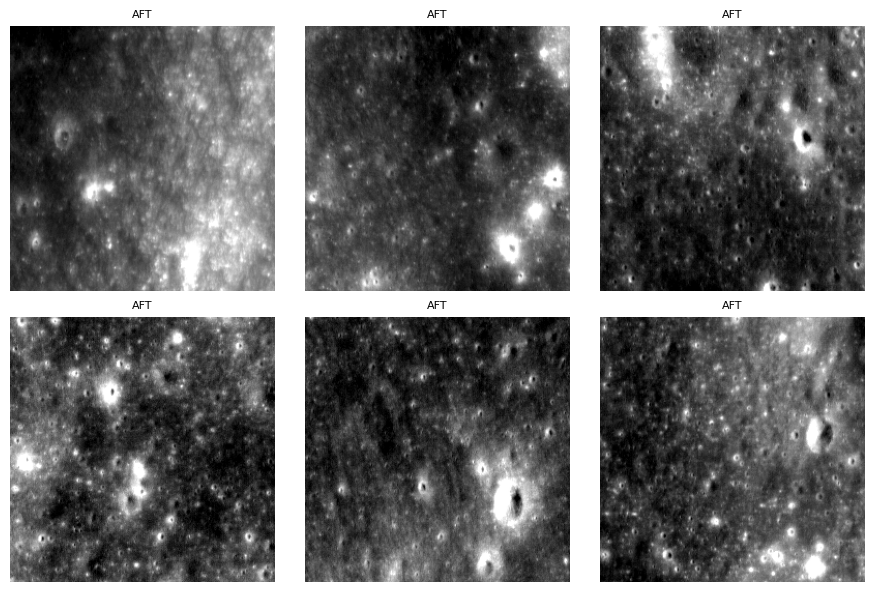

Showing geographic coverage...


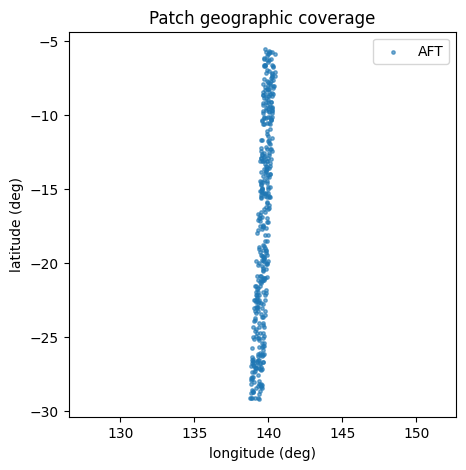


MVP END-TO-END TEST COMPLETE


In [24]:
# ============================================================
# END-TO-END SINGLE-OBSERVATION MVP TEST
# ============================================================

# TMC2_DIR already points to:
# D:\ISRO\TMC_raws
#
# The actual TMC-2 data-point folder does not need to be named
# "mvp_observation". Recursive discovery searches underneath
# TMC2_DIR.

MVP_OBSERVATION_ROOT = TMC2_DIR


def run_mvp_test(
    observation_root: str = MVP_OBSERVATION_ROOT,
    out_dir: str = OUT_ROOT
):

    # --------------------------------------------------------
    # Check input directory
    # --------------------------------------------------------

    if not os.path.isdir(
        observation_root
    ):

        print(
            f"[INFO] {observation_root} "
            f"does not exist yet -- "
            f"check TMC2_DIR and the TMC-2 "
            f"data location, then re-run "
            f"this cell."
        )

        return None

    # --------------------------------------------------------
    # Temporary working directory
    # Used only if ZIP archives need staging.
    # --------------------------------------------------------

    work_dir = tempfile.mkdtemp(
        prefix="tmc2_mvp_"
    )

    try:

        # ----------------------------------------------------
        # Discover ZIP archives
        # ----------------------------------------------------

        zips = discover_tmc2_zips(
            observation_root
        )

        # ----------------------------------------------------
        # Build search roots
        #
        # Always search the actual TMC2 directory.
        # Add extracted ZIP roots only when ZIPs exist.
        # ----------------------------------------------------

        search_roots = [
            observation_root
        ]

        if zips:

            staged_roots = (
                stage_tmc2_zips(
                    zips,
                    work_dir
                )
            )

            search_roots.extend(
                staged_roots
            )

        # ----------------------------------------------------
        # Discover files + build observation groups
        # ----------------------------------------------------

        groups, files_df = (
            build_observation_groups(
                search_roots
            )
        )

        print(
            f"Discovered "
            f"{len(files_df)} TMC-2 files "
            f"-> "
            f"{len(groups)} observation "
            f"group(s)."
        )

        # ----------------------------------------------------
        # No observations found
        # ----------------------------------------------------

        if not groups:

            print(
                "[INFO] No calibrated "
                "NCF/NCN/NCA products "
                "discovered under this root yet."
            )

            return None

        # ----------------------------------------------------
        # MVP output directory
        # ----------------------------------------------------

        mvp_out = os.path.join(
            out_dir,
            "mvp_patches"
        )

        os.makedirs(
            mvp_out,
            exist_ok=True
        )

        # ----------------------------------------------------
        # Process observations
        #
        # IMPORTANT:
        # only_complete=False is intentional for the smoke test.
        #
        # This allows an observation with only AFT, NADIR,
        # or FORE to be processed and flagged rather than
        # discarded.
        # ----------------------------------------------------

        manifest_df = run_tmc2_batch(
            groups,
            search_roots,
            out_dir=mvp_out,
            only_complete=False
        )

        # ----------------------------------------------------
        # No patches produced
        # ----------------------------------------------------

        if len(manifest_df) == 0:

            print(
                "[INFO] No patches were "
                "produced "
                "(check QA logs above)."
            )

            return None

        # ----------------------------------------------------
        # Quality report
        # ----------------------------------------------------

        print(
            "\n" + "=" * 70
        )

        print(
            "MVP PATCH QUALITY REPORT"
        )

        print(
            "=" * 70
        )

        report_quality_stats(
            manifest_df
        )

        # ----------------------------------------------------
        # Save MVP manifest
        # ----------------------------------------------------

        save_manifest(
            manifest_df,
            out_dir=out_dir,
            name="mvp_manifest"
        )

        # ----------------------------------------------------
        # Smoke-test split
        #
        # For a single-observation MVP, everything is temporarily
        # treated as train so the complete Dataset -> DataLoader
        # -> Encoder -> InfoNCE path can be exercised.
        #
        # This is NOT the final scientific train/test split.
        # ----------------------------------------------------

        manifest_df = (
            manifest_df.copy()
        )

        manifest_df["split"] = "train"

        # ----------------------------------------------------
        # Train encoder for one smoke-test epoch
        # ----------------------------------------------------

        batch_size = max(
            1,
            min(
                8,
                len(manifest_df)
            )
        )

        encoder = train_tmc2_encoder(
            manifest_df,
            epochs=1,
            batch_size=batch_size
        )

        # ----------------------------------------------------
        # Generate primary 256-D embeddings
        # ----------------------------------------------------

        embed_df = generate_embeddings(
            encoder,
            manifest_df,
            split="train"
        )

        # ----------------------------------------------------
        # Embedding QA
        # ----------------------------------------------------

        report_embedding_stats(
            embed_df
        )

        # ----------------------------------------------------
        # Save embeddings
        # ----------------------------------------------------

        save_embeddings(
            embed_df,
            out_dir=out_dir,
            name="mvp"
        )

        # ----------------------------------------------------
        # Visual sanity checks
        # ----------------------------------------------------

        if len(manifest_df):

            print(
                "\nShowing sampled TMC-2 patches..."
            )

            show_patch_grid(
                manifest_df,
                n=6
            )

            print(
                "Showing geographic coverage..."
            )

            show_geographic_coverage(
                manifest_df
            )

        print(
            "\n" + "=" * 70
        )

        print(
            "MVP END-TO-END TEST COMPLETE"
        )

        print(
            "=" * 70
        )

        return (
            manifest_df,
            embed_df
        )

    finally:

        # ----------------------------------------------------
        # Remove temporary ZIP staging directory.
        # Real data under TMC2_DIR is untouched.
        # ----------------------------------------------------

        shutil.rmtree(
            work_dir,
            ignore_errors=True
        )


# ============================================================
# RUN MVP TEST
# ============================================================

_mvp_result = run_mvp_test()

In [25]:
# ============================================================
# TMC-2 DISCOVERY DIAGNOSTIC
# ============================================================

files_df = discover_tmc2_files(TMC2_DIR)

print("=" * 80)
print("DISCOVERED TMC-2 FILES")
print("=" * 80)

if len(files_df) == 0:
    print("No TMC-2 files discovered.")
else:
    print(
        files_df[
            [
                "file_name",
                "product_type",
                "camera",
                "category",
                "prd",
                "ext",
                "timestamp",
                "scene_id",
            ]
        ].to_string(index=False)
    )

    print("\n" + "=" * 80)
    print("COUNTS")
    print("=" * 80)

    print("\nBy product type:")
    print(files_df["product_type"].value_counts())

    print("\nBy camera:")
    print(files_df["camera"].value_counts())

    print("\nBy category:")
    print(files_df["category"].value_counts())

    print("\nBy product:")
    print(files_df["prd"].value_counts())

    print("\nCalibrated data-image XML files:")
    cal = files_df[
        (files_df.product_type == "calibrated") &
        (files_df.category == "d") &
        (files_df.prd == "img") &
        (files_df.ext == "xml")
    ]

    if len(cal):
        print(
            cal[
                [
                    "file_name",
                    "camera",
                    "timestamp",
                    "scene_id",
                    "path",
                ]
            ].to_string(index=False)
        )
    else:
        print("NONE FOUND")

DISCOVERED TMC-2 FILES
                                    file_name product_type camera category prd ext                  timestamp                                  scene_id
ch2_tmc_nca_20260813T1023298778_b_brw_d18.png   calibrated    AFT        b brw png 2026-08-13 10:23:29.877800 ch2_tmc_nca_20260813T1023298778_b_brw_d18
ch2_tmc_nca_20260813T1023298778_b_brw_d18.xml   calibrated    AFT        b brw xml 2026-08-13 10:23:29.877800 ch2_tmc_nca_20260813T1023298778_b_brw_d18
ch2_tmc_nca_20260813T1023298778_d_img_d18.img   calibrated    AFT        d img img 2026-08-13 10:23:29.877800 ch2_tmc_nca_20260813T1023298778_d_img_d18
ch2_tmc_nca_20260813T1023298778_d_img_d18.xml   calibrated    AFT        d img xml 2026-08-13 10:23:29.877800 ch2_tmc_nca_20260813T1023298778_d_img_d18
ch2_tmc_nca_20260813T1023298778_g_grd_d18.csv   calibrated    AFT        g grd csv 2026-08-13 10:23:29.877800 ch2_tmc_nca_20260813T1023298778_g_grd_d18
ch2_tmc_nca_20260813T1023298778_g_grd_d18.xml   calibrated    AFT

## 23. Summary / statistics (Sec. 32)

Run this after a full (or partial) batch run to get an overall report.
Also usable directly after the MVP test above.

In [26]:
# ============================================================
# SUMMARY / STATISTICS
# ============================================================

def print_pipeline_summary(
    manifest_df: pd.DataFrame
):

    print("=" * 60)
    print("TMC-2 PIPELINE SUMMARY")
    print("=" * 60)

    if len(manifest_df) == 0:

        print(
            "No patches produced yet -- run the batch driver "
            "(Sec. 15) or the MVP test (Sec. 22) first."
        )

        return

    print(
        f"Total patches: {len(manifest_df)}"
    )

    print(
        "Observations covered:",
        manifest_df.observation_id.nunique()
    )

    if "split" in manifest_df.columns:
        print(
            manifest_df.groupby("split").size()
        )

    report_quality_stats(
        manifest_df
    )

    print("=" * 60)


if (
    "_mvp_result" in dir()
    and _mvp_result is not None
):

    print_pipeline_summary(
        _mvp_result[0]
    )

else:

    print(
        "Run Section 22 (or the full Section 15 "
        "batch driver) first, then call "
        "print_pipeline_summary(manifest_df)."
    )

TMC-2 PIPELINE SUMMARY
Total patches: 400
Observations covered: 1
split
train    400
dtype: int64
Patches by camera:
 camera
AFT    400
Name: count, dtype: int64

Mean valid_fraction: 1.0
Mean saturation_fraction: 0.0
Low-texture flagged: 394 / 400
Geolocation missing: 0 / 400
Ancillary missing: 400 / 400


## 24. Scaling up: full-archive run (train/test split + full training)

Once the MVP test above is confirmed working end-to-end on one
observation, point `TMC2_DIR` (Section 2) at the full archive (or a
folder of `.zip` bundles covering many observations) and run this
cell. It discovers every observation, builds the observation-level
15/5 train/test split (Section 16), runs the batch driver over BOTH
splits, trains the encoder on `train` only, and generates + saves
embeddings for both splits separately.

In [27]:
# ============================================================
# FULL-ARCHIVE RUN (uncomment to execute once TMC2_DIR points at
# the larger dataset -- left inert by default so this notebook
# stays a fast, one-observation-first MVP)
# ============================================================

def run_full_tmc2_pipeline(
    tmc2_dir: str = TMC2_DIR,
    out_dir: str = OUT_ROOT
):

    work_dir = tempfile.mkdtemp(
        prefix="tmc2_full_"
    )

    zips = discover_tmc2_zips(
        tmc2_dir
    )

    search_roots = (
        [tmc2_dir]
        + (
            stage_tmc2_zips(
                zips,
                work_dir
            )
            if zips
            else []
        )
    )

    groups, files_df = build_observation_groups(
        search_roots
    )

    print(
        f"Discovered {len(files_df)} TMC-2 files "
        f"-> {len(groups)} observation group(s) "
        f"({sum(g.is_complete for g in groups)} "
        f"complete NCF+NCN+NCA)."
    )

    manifest_df = run_tmc2_batch(
        groups,
        search_roots,
        out_dir=PATCH_DIR,
        only_complete=True
    )

    save_manifest(
        manifest_df,
        out_dir=out_dir,
        name="tmc2_manifest_full"
    )

    train_ids, test_ids = split_observations(
        manifest_df
    )

    manifest_df = apply_split(
        manifest_df,
        train_ids,
        test_ids
    )

    save_manifest(
        manifest_df,
        out_dir=out_dir,
        name="tmc2_manifest_split"
    )

    encoder = train_tmc2_encoder(
        manifest_df,
        epochs=5,
        batch_size=32
    )

    torch.save(
        encoder.state_dict(),
        os.path.join(
            out_dir,
            "tmc2_encoder.pt"
        )
    )

    train_embed_df = generate_embeddings(
        encoder,
        manifest_df,
        split="train"
    )

    test_embed_df = generate_embeddings(
        encoder,
        manifest_df,
        split="test"
    )

    save_embeddings(
        train_embed_df,
        out_dir=out_dir,
        name="tmc2_train"
    )

    save_embeddings(
        test_embed_df,
        out_dir=out_dir,
        name="tmc2_test"
    )

    print_pipeline_summary(
        manifest_df
    )

    return (
        manifest_df,
        train_embed_df,
        test_embed_df
    )


# Uncomment ONLY when TMC2_DIR points at the full/larger dataset:
# manifest_df, train_embed_df, test_embed_df = run_full_tmc2_pipeline()

print(
    "run_full_tmc2_pipeline() defined -- call it explicitly "
    "once TMC2_DIR points at the larger dataset."
)

run_full_tmc2_pipeline() defined -- call it explicitly once TMC2_DIR points at the larger dataset.
